# MyoGYM - a CNN-ResBiGRU-based Exercise Classification Model

**Based on:** Mekruksavanich & Jitpattanakul (2024), *Appl. Syst. Innov.*, 7(4), 59.  

**Adapted for:**
- IMU-only input (6 channels: accel + gyro), sampling rate auto-detected from filename
- **2 classes**: exercise (1,3) vs exercise (5,5)
- **LOSO** (Leave-One-Subject-Out) cross-validation by participant

---
## 0. Setup & Configuration

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from scipy.signal import butter, filtfilt
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
)
import matplotlib.pyplot as plt
import re
import warnings
warnings.filterwarnings("ignore")
import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"PyTorch: {torch.__version__}")
print(f"CUDA:    {torch.cuda.is_available()}")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device:  {DEVICE}")

PyTorch: 2.10.0+cu128
CUDA:    True
Device:  cuda


In [ ]:
# ============================================================
# CONFIGURATION
# ============================================================

# -- Data --
DATA_PATH = "data/golden_dataset_v10_20Hz.csv"   # <-- change this line per run

# Auto-detect sampling rate from filename (looks for "10Hz", "20Hz", "40Hz", etc.)
_hz_match = re.search(r"(\d+)\s*Hz", DATA_PATH, re.IGNORECASE)
if _hz_match is None:
    raise ValueError(
        f"Could not find sampling rate (e.g. '20Hz') in DATA_PATH: {DATA_PATH}"
    )

# -- Classes to keep: (parent, child) pairs --
# (1,3) = exercise 0, (5,5) = exercise 1
KEEP_PAIRS = [(1, 3), (5, 5)]

# Maps parent value -> model label (must be 0-indexed for CrossEntropyLoss)
LABEL_MAP = {1: 0, 5: 1}
NUM_CLASSES = len(LABEL_MAP)  # 2

# -- Preprocessing --
SAMPLING_RATE = int(_hz_match.group(1))      # Hz
WINDOW_SIZE_SEC  = 2.0      # seconds per window
OVERLAP          = 0.5      # 50% overlap

# -- Training --
EPOCHS        = 100
BATCH_SIZE    = 64
LEARNING_RATE = 0.001
PATIENCE      = 20


# -- Test set from golden_dataset (held out from LOSO and hyperparameter sweep) --
# Used in cell 14 to split the golden dataset. Run the load + filter cells
# first to see which participants exist in golden_dataset, then
# pick 1-2 to hold out here.
TEST_GOLDEN_PARTICIPANTS = [18]   # <-- adjust based on golden dataset participants

# -- Test set from OurData (held out from fine-tuning) --
# Used in cell 47 to split OurData childclasses into fine-tune vs test.
# OurData contains participants [15, 16, 17, 18, 19].
TEST_OURDATA_PARTICIPANTS = [15]

# -- Ablation: which IMU channels to use --
# "accel_AND_gyro" = 6 channels (accel + gyro)  -- baseline
# "accel_only"     = 3 channels (accel only)    -- ablation
# "gyro_only"      = 3 channels (gyro only)     -- another ablation
CHANNEL_MODE = "accel_only"   # <-- "accel_AND_gyro" OR "accel_only OR "gyro_only"

if CHANNEL_MODE == "accel_AND_gyro":
    IMU_COLS = ["x_accel", "y_accel", "z_accel", "x_gyro", "y_gyro", "z_gyro"]
elif CHANNEL_MODE == "accel_only":
    IMU_COLS = ["x_accel", "y_accel", "z_accel"]
elif CHANNEL_MODE == "gyro_only":
    IMU_COLS = ["x_gyro", "y_gyro", "z_gyro"]
else:
    raise ValueError(f"Unknown CHANNEL_MODE: {CHANNEL_MODE}")

NUM_IMU_CHANNELS = len(IMU_COLS)
print(f"Channel mode: {CHANNEL_MODE}  ({NUM_IMU_CHANNELS} channels)")

# -- Derived: quantities that must track sampling rate --
_window_samples = int(WINDOW_SIZE_SEC * SAMPLING_RATE)

# Bandpass: lowcut from physiology (rep cadence ~0.25–0.5 Hz, lowcut
# below that to preserve the fundamental). Highcut from physiology
# (~15 Hz upper bound of voluntary motion), capped below Nyquist at
# low fs so the filter stays well-conditioned.
LOWCUT  = 0.3                                # physiological floor for rep-level motion
HIGHCUT = min(15.0, 0.4 * SAMPLING_RATE)     # physiological ceiling, capped below Nyquist
binding = "Nyquist-bound" if 0.4 * SAMPLING_RATE < 15.0 else "physiology-bound"
print(f"Bandpass:           {LOWCUT}–{HIGHCUT} Hz  ({binding})")


# Architecture is pinned across all sampling rates so depth/capacity
# is held constant for cross-rate comparisons.
CONV_FILTERS = (64, 128, 256, 512)   # always 4 blocks
N_CONV_BLOCKS = len(CONV_FILTERS)

print(f"Sampling rate:      {SAMPLING_RATE} Hz")
print(f"Nyquist:            {SAMPLING_RATE / 2} Hz")
print(f"Window samples:     {_window_samples}")
print(f"CNN conv blocks:    {N_CONV_BLOCKS}  (filters={CONV_FILTERS})")
print(f"Post-CNN seq len:   8  (fixed by AdaptiveAvgPool1d)")

Channel mode: accel_only  (3 channels)
Bandpass:           0.3–8.0 Hz  (Nyquist-bound)
Sampling rate:      20 Hz
Nyquist:            10.0 Hz
Window samples:     40
CNN conv blocks:    4  (filters=(64, 128, 256, 512))
Post-CNN seq len:   8  (fixed by AdaptiveAvgPool1d)


---
## 1. Mount Google Drive & Load Data

In [ ]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [ ]:
# ============================================================
# SET YOUR BASE PATH HERE
# This is the folder that contains our "data" subfolder.
# ============================================================
import os

BASE_PATH = "/content/drive/MyDrive/Spring 2026/Wearable Health Technologies/1A Activity Recognition/Data & Code & Resources/MyoGym Model"
FULL_DATA_PATH = os.path.join(BASE_PATH, DATA_PATH)

print(f"Loading: {FULL_DATA_PATH}")
df_full = pd.read_csv(FULL_DATA_PATH)
print(f"Full dataset: {df_full.shape[0]:,} rows, {df_full.shape[1]} columns")
print(f"Columns: {list(df_full.columns)}")
df_full.head()

Loading: /content/drive/MyDrive/Spring 2026/Wearable Health Technologies/1A Activity Recognition/Data & Code & Resources/MyoGym Model/data/golden_dataset_v10_20Hz.csv
Full dataset: 24,788 rows, 12 columns
Columns: ['x_accel', 'y_accel', 'z_accel', 'x_gyro', 'y_gyro', 'z_gyro', 'parent', 'child', 'participant', 'set', 'ID', 'dataset']


,x_accel,y_accel,z_accel,x_gyro,y_gyro,z_gyro,parent,child,participant,set,ID,dataset
0,-0.607620,0.260122,-0.244656,-3.580708,61.459589,-11.303101,5,5,18,1,38,ourdata
1,0.938619,-0.286055,-0.031800,-18.836250,-37.515571,16.490179,5,5,18,1,38,ourdata
2,-0.383179,0.059054,-0.093280,-33.899180,-2.453326,0.954961,5,5,18,1,38,ourdata
3,0.154184,0.109962,0.244019,-1.578370,8.389933,3.827915,5,5,18,1,38,ourdata
4,-0.075512,-0.099518,-0.049661,-3.277634,17.204920,8.430352,5,5,18,1,38,ourdata


---
## 2. Filter Data — Keep Only Target Exercises

We keep only:
- `(parent=1, child=3)` — exercise class 0
- `(parent=5, child=5)` — exercise class 1

All other data is discarded. We find IDs that contain
at least one row of `(1,3)` or `(5,5)`, then within those IDs keep only
matching rows.

In [ ]:
# Find rows matching target (parent, child) pairs
pair_mask = pd.Series(False, index=df_full.index)
for p, c in KEEP_PAIRS:
    pair_mask |= (df_full["parent"] == p) & (df_full["child"] == c)

df_filtered = df_full[pair_mask].copy().reset_index(drop=True)

# Create model label from parent column
df_filtered["label"] = df_filtered["parent"].map(LABEL_MAP)

print(f"Filtered dataset: {len(df_filtered):,} rows")
print(f"\nClass distribution:")
for (p, c), pair_label in zip(KEEP_PAIRS, LABEL_MAP.values()):
    count = (df_filtered["label"] == pair_label).sum()
    print(f"  parent={p}, child={c}  →  label {pair_label}  →  {count:,} rows")

print(f"\nParticipants: {sorted(df_filtered['participant'].unique())}")
print(f"Unique IDs:   {df_filtered['ID'].nunique()}")

Filtered dataset: 24,788 rows

Class distribution:
  parent=1, child=3  →  label 0  →  15,203 rows
  parent=5, child=5  →  label 1  →  9,585 rows

Participants: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19)]
Unique IDs:   43


In [ ]:
# Quick sanity check: show a sample ID's label sequence
sample_id = df_filtered["ID"].unique()[0]
sample = df_filtered[df_filtered["ID"] == sample_id]
print(f"ID {sample_id}: {len(sample)} rows")
print(f"  Label sequence: {sample['label'].unique()} "
      f"(0=exercise(1,3), 1=exercise(5,5))")
print(f"  Participant: {sample['participant'].iloc[0]}")
print(f"  Parent values: {sample['parent'].unique()}")
print(f"  Child values:  {sample['child'].unique()}")

ID 38: 480 rows
  Label sequence: [1] (0=exercise(1,3), 1=exercise(5,5))
  Participant: 18
  Parent values: [5]
  Child values:  [5]


---
## 3. Preprocessing

**Denoising:** Zero-phase Butterworth bandpass per channel, applied per ID. The band is chosen from physiology, not from the source paper:

Lowcut = 0.3 Hz removes gravity, sensor bias, and slow orientation drift while preserving the fundamental of a slow rep (~0.25–0.5 Hz for a 2–4 second rep).
Highcut = `min(15 Hz, 0.4 × fs)` keeps the full band of voluntary human motion (which dies off above ~15 Hz) while staying safely below Nyquist at low sampling rates. At 40 Hz and above, the highcut is bound by physiology (15 Hz) and the filter behaves the way you'd want for biomechanical signals. At 10 Hz it's bound by Nyquist (4 Hz) and we lose some rep-shape detail — a fundamental limit of undersampling that no filter can fix.

**Unit conversion:** Acceleration is converted from G's to m/s² (×9.81)
once per dataset, before denoising.

**Normalization:** Per-channel min–max scaling fit on **training data
only** and applied to validation/test data — never fit globally.

**Segmentation** is done per ID to avoid windows that span different
recordings.

In [ ]:
class IMUPreprocessor:
    """
    Preprocessing pipeline for IMU data. Sampling rate, window size, and
    bandpass limits are all configurable so the same class can handle
    10 Hz, 20 Hz, 40 Hz, or other rates.

    Steps (in order):
      1. Denoise per ID  — zero-phase Butterworth bandpass, per channel,
                           applied independently to each recording so the
                           filter never smears across ID boundaries.
      2. Segment per ID  — sliding window with majority-vote labels.

    Normalization is intentionally NOT done here. It must be fit on
    training data only (after the train/test split, and inside each
    LOSO fold), so it lives outside this class.
    """

    def __init__(self, sampling_rate=20, window_size_sec=2.0, overlap=0.5,
                 lowcut=1.0, highcut=9.0, filter_order=6):
        self.fs = sampling_rate
        self.window_size = int(window_size_sec * sampling_rate)
        self.step_size = int(self.window_size * (1.0 - overlap))
        self.lowcut = lowcut
        self.highcut = highcut
        self.filter_order = filter_order

        # Pre-compute filter coefficients once
        nyq = 0.5 * self.fs
        lo = self.lowcut / nyq
        hi = min(self.highcut / nyq, 0.99)
        if lo <= 0 or lo >= hi:
            raise ValueError(
                f"Invalid filter band: lowcut={self.lowcut}, "
                f"highcut={self.highcut}, fs={self.fs}"
            )
        self._b, self._a = butter(self.filter_order, [lo, hi], btype="band")
        self._min_filt_len = 3 * max(len(self._b), len(self._a))

        print(f"  Sampling rate:  {self.fs} Hz")
        print(f"  Nyquist:        {nyq} Hz")
        print(f"  Bandpass:       {self.lowcut}–{self.highcut} Hz")
        print(f"  Window size:    {self.window_size} samples ({window_size_sec}s)")
        print(f"  Step size:      {self.step_size} samples ({overlap*100:.0f}% overlap)")

    def denoise(self, data):
        """Zero-phase bandpass per channel on a single contiguous recording."""
        out = np.zeros_like(data, dtype=np.float64)
        for ch in range(data.shape[1]):
            if data.shape[0] > self._min_filt_len:
                out[:, ch] = filtfilt(self._b, self._a, data[:, ch])
            else:
                out[:, ch] = data[:, ch]  # too short to filter safely
        return out

    def segment_single(self, data, labels):
        """Sliding window on a single continuous sequence (assumes denoised)."""
        X, y = [], []
        T = data.shape[0]
        for s in range(0, T - self.window_size + 1, self.step_size):
            window = data[s : s + self.window_size]
            wlabels = labels[s : s + self.window_size]
            vals, cnts = np.unique(wlabels, return_counts=True)
            X.append(window)
            y.append(vals[cnts.argmax()])
        return X, y

    def segment_by_id(self, df, imu_cols, label_col="label", id_col="ID",
                      participant_col="participant"):
        """
        For each ID: denoise that ID's IMU array, then sliding-window it.
        Returns:
            X:            (N, window_size, channels)  -- denoised, NOT normalized
            y:            (N,)
            participants: (N,)
        """
        all_X, all_y, all_participants = [], [], []

        for uid in df[id_col].unique():
            subset = df[df[id_col] == uid]
            imu = subset[imu_cols].values.astype(np.float64)
            labels = subset[label_col].values
            participant = subset[participant_col].iloc[0]

            if len(imu) < self.window_size:
                continue

            imu = self.denoise(imu)  # per-ID denoise — no boundary smearing
            windows, window_labels = self.segment_single(imu, labels)

            all_X.extend(windows)
            all_y.extend(window_labels)
            all_participants.extend([participant] * len(windows))

        return (np.array(all_X, dtype=np.float32),
                np.array(all_y, dtype=np.int64),
                np.array(all_participants))


class MinMaxScaler3D:
    """
    Per-channel min-max scaler for arrays shaped (N_windows, T, C).
    Fit on training windows only; apply to val/test/inference windows.
    """
    def fit(self, X):
        # min/max per channel, computed across windows AND timesteps
        self.min_ = X.min(axis=(0, 1))
        self.max_ = X.max(axis=(0, 1))
        denom = self.max_ - self.min_
        denom[denom == 0] = 1.0
        self._denom = denom
        return self

    def transform(self, X):
        out = (X - self.min_) / self._denom
        return np.clip(out, 0.0, 1.0).astype(np.float32)

    def fit_transform(self, X):
        return self.fit(X).transform(X)

In [ ]:
# Run preprocessing
print("Initializing preprocessor...")
pp = IMUPreprocessor(
    sampling_rate=SAMPLING_RATE,
    window_size_sec=WINDOW_SIZE_SEC,
    overlap=OVERLAP,
    lowcut=LOWCUT,
    highcut=HIGHCUT,
)

# Step 0: Convert acceleration from G's to m/s² (idempotent — guarded by flag)
accel_cols = ["x_accel", "y_accel", "z_accel"]
if not df_filtered.attrs.get("accel_in_ms2", False):
    print("\nConverting acceleration from G's to m/s²...")
    df_filtered[accel_cols] = df_filtered[accel_cols] * 9.81
    df_filtered.attrs["accel_in_ms2"] = True
else:
    print("\nAccel already in m/s² — skipping conversion.")
print(f"  Accel range: "
      f"[{df_filtered[accel_cols].min().min():.2f}, "
      f"{df_filtered[accel_cols].max().max():.2f}] m/s²")

# Step 1+2: Denoise (per ID, inside segment_by_id) and segment
print("\nSegmenting per ID (denoise happens per-ID inside)...")
X, y, participants = pp.segment_by_id(df_filtered, IMU_COLS)

# NOTE: X is denoised but NOT normalized. Normalization is fit on training
# data only — see cell 14 (final train/test) and run_loso (per-fold).

print(f"\nResult:")
print(f"  X: {X.shape}  (windows × timesteps × channels)")
print(f"  y: {y.shape}  ({len(np.unique(y))} classes)")
print(f"  Participants: {np.unique(participants)}")
print(f"\nWindows per class:")
for label_val, label_name in zip([0, 1], ["exercise (1,3)", "exercise (5,5)"]):
    print(f"  Label {label_val} ({label_name}): {(y == label_val).sum()}")

Initializing preprocessor...
  Sampling rate:  20 Hz
  Nyquist:        10.0 Hz
  Bandpass:       0.3–8.0 Hz
  Window size:    40 samples (2.0s)
  Step size:      20 samples (50% overlap)

Converting acceleration from G's to m/s²...
  Accel range: [-10.11, 12.61] m/s²

Segmenting per ID (denoise happens per-ID inside)...

Result:
  X: (1176, 40, 3)  (windows × timesteps × channels)
  y: (1176,)  (2 classes)
  Participants: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]

Windows per class:
  Label 0 (exercise (1,3)): 725
  Label 1 (exercise (5,5)): 451


---
## 4. Train / Test Split

Hold out one or more participants as a **final test set** that is never touched during LOSO development. LOSO runs only on the remaining "train" participants.

- **Train set** → used for LOSO evaluation and model training
- **Test set** → evaluated once at the very end for an unbiased performance estimate

In [ ]:
# Split into train and test based on participant
test_mask = np.isin(participants, TEST_GOLDEN_PARTICIPANTS)
train_mask  = ~test_mask

X_train,  y_train,  participants_train  = X[train_mask],  y[train_mask],  participants[train_mask]
X_test, y_test, participants_test = X[test_mask], y[test_mask], participants[test_mask]

print(f"Test participants: {TEST_GOLDEN_PARTICIPANTS}")
print(f"Train  participants: {sorted(np.unique(participants_train))}")
print(f"\nTrain  set: {X_train.shape[0]:,} windows")
print(f"Test set: {X_test.shape[0]:,} windows")

print(f"\nTrain class distribution:")
for lv, ln in zip([0, 1], ["exercise (1,3)", "exercise (5,5)"]):
    print(f"  Label {lv} ({ln}): {(y_train == lv).sum()}")

print(f"\nTest class distribution:")
for lv, ln in zip([0, 1], ["exercise (1,3)", "exercise (5,5)"]):
    print(f"  Label {lv} ({ln}): {(y_test == lv).sum()}")

# ---- Keep raw (denoised but un-normalized) copies for LOSO ----
# run_loso refits normalization per fold on training participants only,
# so it needs the un-normalized arrays.
X_train_raw = X_train.copy()
X_test_raw  = X_test.copy()

# ---- Fit final scaler on training data ONLY ----
# Used by the final-test model in cell 33 and for OurData inference in cells 43+.
final_scaler = MinMaxScaler3D().fit(X_train_raw)
X_train = final_scaler.transform(X_train_raw)
X_test  = final_scaler.transform(X_test_raw)

print(f"\nNormalized: train range [{X_train.min():.3f}, {X_train.max():.3f}], "
      f"test range [{X_test.min():.3f}, {X_test.max():.3f}]")

Test participants: [18]
Train  participants: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(19)]

Train  set: 1,091 windows
Test set: 85 windows

Train class distribution:
  Label 0 (exercise (1,3)): 681
  Label 1 (exercise (5,5)): 410

Test class distribution:
  Label 0 (exercise (1,3)): 44
  Label 1 (exercise (5,5)): 41

Normalized: train range [0.000, 1.000], test range [0.133, 1.000]


---
## 5. Model — CNN-ResBiGRU (Section 3.4)

In [ ]:
class ResBiGRUBlock(nn.Module):
    """
    Residual Bidirectional GRU block (Section 3.4.2, Figure 6, Eqs. 4-6).

    Each stacked layer:
        h = BiGRU(x)           # forward + backward GRU, concatenated
        r = Linear(x)          # project input to match h's dimension
        x = LayerNorm(r + h)   # residual connection + normalization
    """

    def __init__(self, input_dim, hidden=128, n_layers=2):
        super().__init__()
        self.blocks = nn.ModuleList()
        dim = input_dim
        for _ in range(n_layers):
            self.blocks.append(nn.ModuleDict({
                "gru":  nn.GRU(dim, hidden, batch_first=True, bidirectional=True),
                "proj": nn.Linear(dim, hidden * 2, bias=False),
                "ln":   nn.LayerNorm(hidden * 2),
            }))
            dim = hidden * 2

    def forward(self, x):
        for blk in self.blocks:
            h, _ = blk["gru"](x)
            r = blk["proj"](x)
            x = blk["ln"](r + h)
        return x

In [ ]:
class CNNResBiGRU(nn.Module):
    def __init__(self, in_channels=6, num_classes=2,
                 conv_filters=(64, 128, 256, 512), kernel=3,
                 conv_drop=0.3, gru_units=128, gru_layers=2, dense=128,
                 post_cnn_len=8):
        super().__init__()

        # Stride-1 conv stack — no pooling here, so no length collapse
        conv_list = []
        ch = in_channels
        for f in conv_filters:
            conv_list.extend([
                nn.Conv1d(ch, f, kernel, padding=kernel // 2),
                nn.BatchNorm1d(f),
                nn.ReLU(),
                nn.Dropout(conv_drop),
            ])
            ch = f
        self.conv = nn.Sequential(*conv_list)

        # Collapse any input length to a fixed post-CNN length.
        # This is the key change: same downstream sequence regardless of fs.
        self.adaptive_pool = nn.AdaptiveAvgPool1d(post_cnn_len)

        self.resbigru = ResBiGRUBlock(ch, gru_units, gru_layers)
        self.head = nn.Sequential(
            nn.Linear(gru_units * 2, dense),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(dense, num_classes),
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)        # (B, T, C) → (B, C, T)
        x = self.conv(x)              # (B, C', T)  -- T unchanged
        x = self.adaptive_pool(x)     # (B, C', post_cnn_len)
        x = x.permute(0, 2, 1)        # (B, post_cnn_len, C')
        x = self.resbigru(x)
        x = x.mean(dim=1)
        return self.head(x)

In [ ]:
# Quick architecture check
test_model = CNNResBiGRU(
    in_channels=NUM_IMU_CHANNELS,
    num_classes=NUM_CLASSES,
    conv_filters=CONV_FILTERS,
).to(DEVICE)
test_input = torch.randn(2, pp.window_size, NUM_IMU_CHANNELS).to(DEVICE)
test_output = test_model(test_input)

n_params = sum(p.numel() for p in test_model.parameters())
print(f"Input shape:  {tuple(test_input.shape)}")
print(f"Output shape: {tuple(test_output.shape)}")
print(f"Parameters:   {n_params:,}")

del test_model, test_input, test_output

Input shape:  (2, 40, 3)
Output shape: (2, 2)
Parameters:   1,539,842


---
## 6. Hyperparameter Search via LOSO

**Random search** over hyperparameter configurations. Each candidate runs a full
Leave-One-Subject-Out sweep on the Train participants. The configuration with the
best mean F1 is selected for the final model.

### How LOSO Cross-Validation Works (and Why We're Using It This Way)

We want a reliable estimate of how well our model will perform on people it has never seen before. The simplest way to measure this would be to split our participants into a training group and a validation group — but that gives us exactly one number, and that number depends heavily on which participants happened to end up in which group. One unlucky split could make a good model look bad, or vice versa.

**Leave-One-Subject-Out (LOSO)** solves this by running every possible one-participant holdout. If we have 4 Train participants, we train 4 separate models: the first holds out participant A and trains on B, C, D. The second holds out B and trains on A, C, D. And so on. Each model is trained completely from scratch — there's no weight carryover between folds. For each fold, the held-out participant acts as the validation set, giving us an accuracy score. At the end, we have 4 scores, one per participant. Averaging them gives us a much more robust estimate than any single train/val split could.

**Why run LOSO once per hyperparameter configuration?** Our hyperparameter search is trying to find the combination of learning rate, batch size, epochs, and patience that produces the best-generalizing model. Since LOSO is our measurement tool for "how well does this generalize," we need to apply it consistently to every configuration we're comparing. A single configuration runs one full LOSO sweep across all folds and produces one aggregate F1 score. We then compare aggregate scores across configurations to pick the winner. Critically, we do **not** change hyperparameters between folds within a single sweep — if we did, the aggregate score wouldn't represent any coherent configuration and we'd be subtly overfitting our tuning to specific participants.

**Why random search instead of trying every combination?** A full grid search over our parameter grid would mean running LOSO for every possible combination, which adds up quickly in compute time. Random search samples a subset of combinations and usually finds a nearly-optimal configuration in a fraction of the time, because in practice only one or two hyperparameters tend to meaningfully affect results — and random sampling covers those well.

**This was done already once in the 20Hz accel_AND_gyro config. And one set of hyperparameters were chosen and used throughout all other notebooks.**

**Test participants are held out from all of this.** The participant(s) in `TEST_GOLDEN_PARTICIPANTS` do not appear in any LOSO fold — not for training, not for validation. They exist purely for the final evaluation at the very end, once we've picked our winning hyperparameters and trained the final model on all Train participants. This guarantees that our reported test accuracy reflects performance on data the model has truly never seen during training.

In [ ]:
def train_one_fold(model, X_tr, y_tr, X_va, y_va, device,
                   epochs=100, batch_size=64, lr=1e-3, patience=15,
                   verbose=True):
    """
    Train a single LOSO fold with early stopping.

    Returns:
        model:   Best model (weights restored)
        history: Dict of training curves
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=5, min_lr=1e-6)

    X_tr_t = torch.FloatTensor(X_tr).to(device)
    y_tr_t = torch.LongTensor(y_tr).to(device)
    X_va_t = torch.FloatTensor(X_va).to(device)
    y_va_t = torch.LongTensor(y_va).to(device)
    train_dl = DataLoader(TensorDataset(X_tr_t, y_tr_t),
                          batch_size=batch_size, shuffle=True)

    best_val_loss, wait, best_state = float("inf"), 0, None
    history = {"train_loss": [], "val_loss": [], "val_acc": []}

    for epoch in range(epochs):
        # Train
        model.train()
        epoch_loss, n_batches = 0.0, 0
        for xb, yb in train_dl:
            optimizer.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            n_batches += 1
        avg_train_loss = epoch_loss / n_batches

        # Validate
        model.eval()
        with torch.no_grad():
            val_logits = model(X_va_t)
            val_loss = loss_fn(val_logits, y_va_t).item()
            val_acc = (val_logits.argmax(1) == y_va_t).float().mean().item()

        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        scheduler.step(val_loss)
        cur_lr = optimizer.param_groups[0]["lr"]

        if verbose and (epoch + 1) % 10 == 0:
            print(f"    Epoch {epoch+1:3d}  "
                  f"train_loss={avg_train_loss:.4f}  "
                  f"val_loss={val_loss:.4f}  "
                  f"val_acc={val_acc:.4f}  lr={cur_lr:.1e}")

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss, wait = val_loss, 0
            best_state = {k: v.cpu().clone()
                          for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= patience:
                if verbose:
                    print(f"    Early stopping at epoch {epoch+1}")
                break

    # Restore best weights
    if best_state is not None:
        model.load_state_dict(best_state)
        model = model.to(device)

    return model, history

In [ ]:
def run_loso(X, y, participants, num_classes, device,
             epochs=100, batch_size=64, lr=1e-3, patience=15):
    """
    Leave-One-Subject-Out cross-validation.

    Normalization is refit per fold on the training participants only,
    then applied to the held-out participant. This avoids leaking the
    held-out participant's value range into the model's input scale.
    """
    logo = LeaveOneGroupOut()
    unique_participants = np.unique(participants)
    n_folds = len(unique_participants)

    print(f"LOSO: {n_folds} folds (one per participant)")
    print(f"Participants: {sorted(unique_participants)}")

    results = {
        "participant": [], "acc": [], "prec": [], "rec": [],
        "f1": [], "loss": [], "histories": [],
        "n_train": [], "n_val": [],
        "all_y_true": [], "all_y_pred": [],
        "fold_y_true": [], "fold_y_pred": [],   # NEW: per-fold for cell 39
    }

    for fold, (tr_idx, va_idx) in enumerate(logo.split(X, y, participants)):
        held_out = participants[va_idx[0]]
        print(f"\n{'═'*55}")
        print(f"  Fold {fold+1}/{n_folds} — Hold out participant {held_out}")
        print(f"  Train: {len(tr_idx)} windows  |  Val: {len(va_idx)} windows")
        print(f"{'═'*55}")

        # Per-fold normalization: fit on training participants only
        fold_scaler = MinMaxScaler3D().fit(X[tr_idx])
        X_tr_fold = fold_scaler.transform(X[tr_idx])
        X_va_fold = fold_scaler.transform(X[va_idx])

        # Build fresh model
        model = CNNResBiGRU(
            in_channels=X.shape[2],
            num_classes=num_classes,
            conv_filters=CONV_FILTERS,
        ).to(device)

        if fold == 0:
            n_params = sum(p.numel() for p in model.parameters())
            print(f"  Parameters: {n_params:,}")

        # Train
        model, history = train_one_fold(
            model, X_tr_fold, y[tr_idx], X_va_fold, y[va_idx],
            device=device, epochs=epochs, batch_size=batch_size,
            lr=lr, patience=patience,
        )

        # Evaluate
        model.eval()
        with torch.no_grad():
            X_va_t = torch.FloatTensor(X_va_fold).to(device)
            y_pred = model(X_va_t).argmax(1).cpu().numpy()
        y_true = y[va_idx]

        acc  = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
        rec  = recall_score(y_true, y_pred, average="macro", zero_division=0)
        f1   = f1_score(y_true, y_pred, average="macro", zero_division=0)

        results["participant"].append(held_out)
        results["acc"].append(acc)
        results["prec"].append(prec)
        results["rec"].append(rec)
        results["f1"].append(f1)
        results["loss"].append(min(history["val_loss"]))
        results["histories"].append(history)
        results["n_train"].append(len(tr_idx))
        results["n_val"].append(len(va_idx))
        results["all_y_true"].extend(y_true)
        results["all_y_pred"].extend(y_pred)
        results["fold_y_true"].append(y_true)
        results["fold_y_pred"].append(y_pred)

        print(f"\n  Participant {held_out} =>  "
              f"Acc: {acc*100:.2f}%  F1: {f1*100:.2f}%")

    return results

In [ ]:
# # ============================================================
# # Random Hyperparameter Search over full LOSO
# # ============================================================
# import random

# # Define search space
# param_grid = {
#     "lr":         [1e-3, 5e-4, 1e-4],
#     "batch_size":  [32, 64],
#     "epochs":      [50, 75, 100],
#     "patience":    [10, 15, 20],
# }

# # Sample N random configurations (set to however many you can afford)
# N_SAMPLES = 10
# random.seed(42)

# all_combos = [
#     dict(zip(param_grid.keys(), vals))
#     for vals in __import__("itertools").product(*param_grid.values())
# ]
# sampled_configs = random.sample(all_combos, min(N_SAMPLES, len(all_combos)))

# print(f"Search space: {len(all_combos)} total combinations")
# print(f"Sampling {len(sampled_configs)} random configurations\n")

# sweep_results = []

# for i, config in enumerate(sampled_configs):
#     print(f"\n{'='*60}")
#     print(f"  Config {i+1}/{len(sampled_configs)}: {config}")
#     print(f"{'='*60}")

#     loso_out = run_loso(
#         X_train, y_train, participants_train,
#         num_classes=NUM_CLASSES,
#         device=DEVICE,
#         epochs=config["epochs"],
#         batch_size=config["batch_size"],
#         lr=config["lr"],
#         patience=config["patience"],
#     )

#     mean_f1  = np.mean(loso_out["f1"])
#     std_f1   = np.std(loso_out["f1"])
#     mean_acc = np.mean(loso_out["acc"])

#     sweep_results.append({
#         **config,
#         "mean_f1": mean_f1,
#         "std_f1": std_f1,
#         "mean_acc": mean_acc,
#         "loso_output": loso_out,  # keep full results for the winner
#     })

#     print(f"  → Mean F1: {mean_f1*100:.2f}% (±{std_f1*100:.2f}%)  "
#           f"Mean Acc: {mean_acc*100:.2f}%")

# # ---- Pick the best config ----
# sweep_df = pd.DataFrame([{k: v for k, v in r.items() if k != "loso_output"}
#                           for r in sweep_results])
# sweep_df = sweep_df.sort_values("mean_f1", ascending=False).reset_index(drop=True)

# print(f"\n\n{'='*60}")
# print("  SWEEP RESULTS (sorted by Mean F1)")
# print(f"{'='*60}")
# display(sweep_df.round(4))

# # Store best config and its LOSO output for downstream cells
# best_idx = sweep_df.index[0]
# best_config = sampled_configs[sweep_results.index(
#     [r for r in sweep_results
#      if r["mean_f1"] == sweep_df.iloc[0]["mean_f1"]][0]
# )]
# results = [r for r in sweep_results
#            if r["mean_f1"] == sweep_df.iloc[0]["mean_f1"]][0]["loso_output"]

# best_lr         = best_config["lr"]
# best_batch_size = best_config["batch_size"]
# best_epochs     = best_config["epochs"]
# best_patience   = best_config["patience"]

# print(f"\n✓ Best configuration:")
# print(f"  lr={best_lr}, batch_size={best_batch_size}, "
#       f"epochs={best_epochs}, patience={best_patience}")
# print(f"  Mean F1: {np.mean(results['f1'])*100:.2f}% "
#       f"(±{np.std(results['f1'])*100:.2f}%)")

In [ ]:
# ============================================================
# LOSO with fixed hyperparameters (sweep skipped)
# ============================================================
# Hyperparameter search was run previously; we're selecting a chosen
# config and running LOSO once instead of sweeping.

# DO NOT change between sampling-rate runs — same hyperparameters across rates is required for the cross-rate comparison.

best_lr         = 1e-3
best_batch_size = 64
best_epochs     = 100
best_patience   = 20

print(f"Running LOSO with fixed config:")
print(f"  lr={best_lr}, batch_size={best_batch_size}, "
      f"epochs={best_epochs}, patience={best_patience}\n")

results = run_loso(
    X_train_raw, y_train, participants_train,
    num_classes=NUM_CLASSES,
    device=DEVICE,
    epochs=best_epochs,
    batch_size=best_batch_size,
    lr=best_lr,
    patience=best_patience,
)

print(f"\n{'='*60}")
print(f"  LOSO COMPLETE")
print(f"{'='*60}")
print(f"  Mean F1:  {np.mean(results['f1'])*100:.2f}% "
      f"(±{np.std(results['f1'])*100:.2f}%)")
print(f"  Mean Acc: {np.mean(results['acc'])*100:.2f}% "
      f"(±{np.std(results['acc'])*100:.2f}%)")

Running LOSO with fixed config:
  lr=0.001, batch_size=64, epochs=100, patience=20

LOSO: 18 folds (one per participant)
Participants: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(19)]

═══════════════════════════════════════════════════════
  Fold 1/18 — Hold out participant 1
  Train: 1059 windows  |  Val: 32 windows
═══════════════════════════════════════════════════════
  Parameters: 1,539,842
    Epoch  10  train_loss=0.0423  val_loss=1.5242  val_acc=0.6250  lr=1.0e-03
    Epoch  20  train_loss=0.0160  val_loss=1.4449  val_acc=0.7188  lr=2.5e-04
    Early stopping at epoch 28

  Participant 1 =>  Acc: 100.00%  F1: 100.00%

═══════════════════════════════════════════════════════
  Fold 2/18 — Hold out participant 2
  Train: 1055 windows  |  Val: 36 windows
═══════════════════════════════════

---
## 7. LOSO Results Summary

In [ ]:
# Per-participant results table
results_df = pd.DataFrame({
    "Participant":  results["participant"],
    "Train Windows": results["n_train"],
    "Val Windows":   results["n_val"],
    "Accuracy (%)":  [a * 100 for a in results["acc"]],
    "Precision (%)":  [p * 100 for p in results["prec"]],
    "Recall (%)":    [r * 100 for r in results["rec"]],
    "F1-score (%)":  [f * 100 for f in results["f1"]],
    "Best Val Loss": results["loss"],
})

print("Per-Participant Results (LOSO)")
print("=" * 70)
display(results_df.round(2))

print(f"\nOverall Averages:")
print(f"  Accuracy:  {np.mean(results['acc'])*100:.2f}% "
      f"(+/- {np.std(results['acc'])*100:.2f}%)")
print(f"  Precision: {np.mean(results['prec'])*100:.2f}% "
      f"(+/- {np.std(results['prec'])*100:.2f}%)")
print(f"  Recall:    {np.mean(results['rec'])*100:.2f}% "
      f"(+/- {np.std(results['rec'])*100:.2f}%)")
print(f"  F1-score:  {np.mean(results['f1'])*100:.2f}% "
      f"(+/- {np.std(results['f1'])*100:.2f}%)")

Per-Participant Results (LOSO)


,Participant,Train Windows,Val Windows,Accuracy (%),Precision (%),Recall (%),F1-score (%),Best Val Loss
0,1,1059,32,100.00,100.00,100.00,100.00,0.00
1,2,1055,36,100.00,100.00,100.00,100.00,0.00
2,3,1072,19,100.00,100.00,100.00,100.00,0.00
3,4,1080,11,100.00,100.00,100.00,100.00,0.00
4,5,1061,30,100.00,100.00,100.00,100.00,0.00
5,6,1070,21,100.00,100.00,100.00,100.00,0.00
6,7,1071,20,100.00,100.00,100.00,100.00,0.00
7,8,1071,20,100.00,100.00,100.00,100.00,0.00
8,9,1058,33,100.00,100.00,100.00,100.00,0.00
9,10,1066,25,92.00,50.00,46.00,47.92,0.25



Overall Averages:
  Accuracy:  98.39% (+/- 2.96%)
  Precision: 96.04% (+/- 11.46%)
  Recall:    95.92% (+/- 12.32%)
  F1-score:  95.93% (+/- 11.92%)


---
## 8. Visualize Training Curves

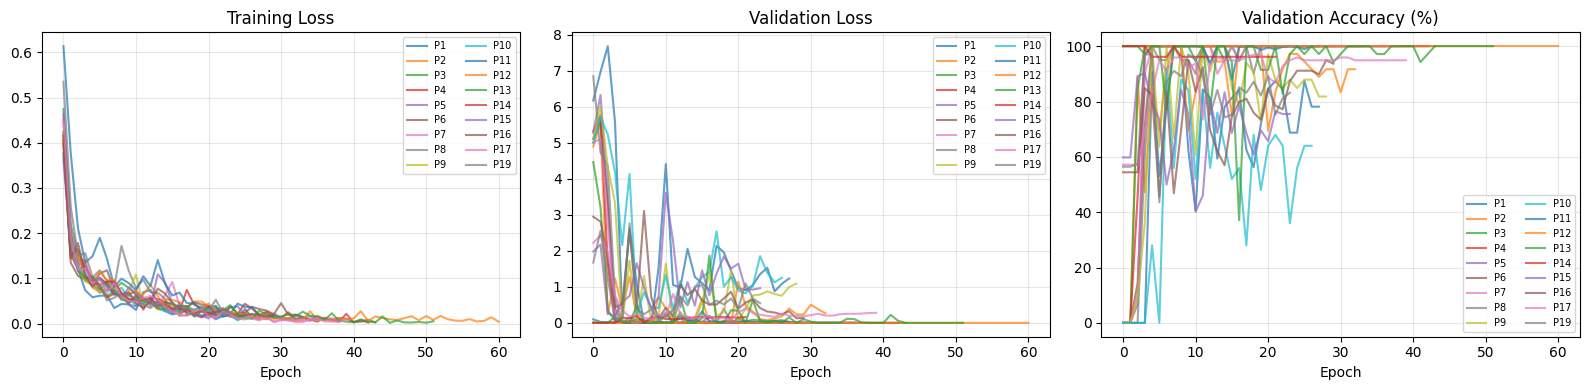

In [ ]:
n_folds = len(results["histories"])
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for i, hist in enumerate(results["histories"]):
    p = results["participant"][i]
    axes[0].plot(hist["train_loss"], alpha=0.7, label=f"P{p}")
    axes[1].plot(hist["val_loss"], alpha=0.7, label=f"P{p}")
    axes[2].plot(np.array(hist["val_acc"]) * 100, alpha=0.7, label=f"P{p}")

axes[0].set_title("Training Loss")
axes[1].set_title("Validation Loss")
axes[2].set_title("Validation Accuracy (%)")

for ax in axes:
    ax.set_xlabel("Epoch")
    ax.legend(fontsize=7, ncol=2)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

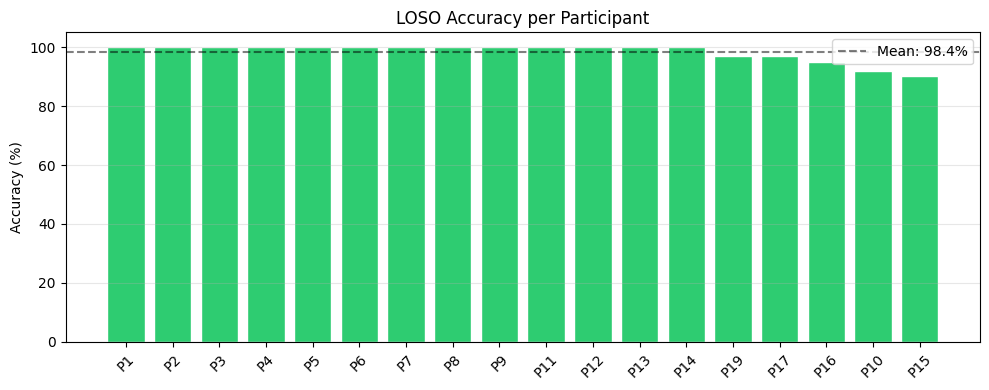

In [ ]:
# Per-participant accuracy bar chart
fig, ax = plt.subplots(figsize=(10, 4))

participants_sorted = sorted(zip(results["participant"], results["acc"]),
                             key=lambda x: x[1], reverse=True)
ps, accs = zip(*participants_sorted)
colors = ["#2ecc71" if a >= 0.8 else "#e67e22" if a >= 0.6 else "#e74c3c"
          for a in accs]

ax.bar(range(len(ps)), [a * 100 for a in accs], color=colors, edgecolor="white")
ax.set_xticks(range(len(ps)))
ax.set_xticklabels([f"P{p}" for p in ps], rotation=45)
ax.set_ylabel("Accuracy (%)")
ax.set_title("LOSO Accuracy per Participant")
ax.axhline(y=np.mean(results["acc"]) * 100, color="black",
           linestyle="--", alpha=0.5, label=f"Mean: {np.mean(results['acc'])*100:.1f}%")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

---
## 9. LOSO Confusion Matrix (Aggregated)

In [ ]:
# Use predictions already collected during LOSO (no retraining needed)
all_y_true = np.array(results["all_y_true"])
all_y_pred = np.array(results["all_y_pred"])

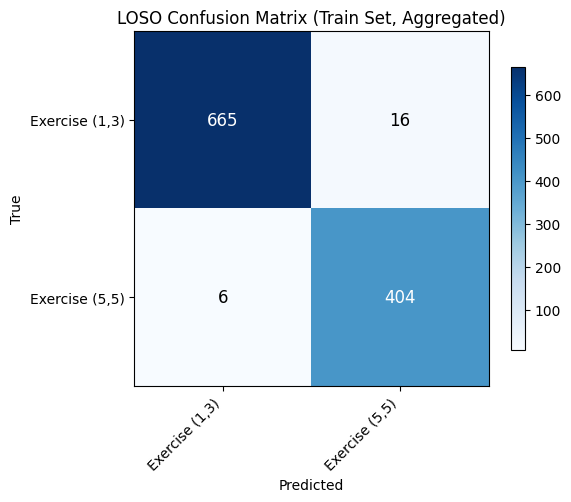


Classification Report:
                precision    recall  f1-score   support

Exercise (1,3)     0.9911    0.9765    0.9837       681
Exercise (5,5)     0.9619    0.9854    0.9735       410

      accuracy                         0.9798      1091
     macro avg     0.9765    0.9809    0.9786      1091
  weighted avg     0.9801    0.9798    0.9799      1091



In [ ]:
# Plot confusion matrix
class_names = ["Exercise (1,3)", "Exercise (5,5)"]
cm = confusion_matrix(all_y_true, all_y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(NUM_CLASSES))
ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        ax.text(j, i, f"{cm[i, j]}", ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black",
                fontsize=12)

fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("LOSO Confusion Matrix (Train Set, Aggregated)", fontsize=12)
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(all_y_true, all_y_pred,
                            target_names=class_names, digits=4))

---
## 10. Final Test Evaluation

Train on **all Train participants** using the **best hyperparameters from the sweep**,
evaluate on the **held-out test participants** once.

In [ ]:
print(f"Training on all Train data ({X_train.shape[0]} windows)...")
print(f"Testing on held-out participants {TEST_GOLDEN_PARTICIPANTS} ({X_test.shape[0]} windows)...")
print(f"Using best config: lr={best_lr}, batch_size={best_batch_size}, "
      f"epochs={best_epochs}, patience={best_patience}")

# Build and train model on all Train data with best hyperparameters
test_model = CNNResBiGRU(
    in_channels=NUM_IMU_CHANNELS,
    num_classes=NUM_CLASSES,
    conv_filters=CONV_FILTERS,
).to(DEVICE)

optimizer = torch.optim.Adam(test_model.parameters(), lr=best_lr)
loss_fn = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=5, min_lr=1e-6)

X_train_t = torch.FloatTensor(X_train).to(DEVICE)
y_train_t = torch.LongTensor(y_train).to(DEVICE)
train_dl = DataLoader(TensorDataset(X_train_t, y_train_t),
                      batch_size=best_batch_size, shuffle=True)

test_model.train()
for epoch in range(best_epochs):
    total_loss, n = 0.0, 0
    for xb, yb in train_dl:
        optimizer.zero_grad()
        loss = loss_fn(test_model(xb), yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        n += 1
    avg_loss = total_loss / n
    scheduler.step(avg_loss)
    if (epoch + 1) % 10 == 0:
        print(f"  Epoch {epoch+1:3d}  loss={avg_loss:.4f}  "
              f"lr={optimizer.param_groups[0]['lr']:.1e}")

# Final predictions on test set
test_model.eval()
with torch.no_grad():
    X_test_t = torch.FloatTensor(X_test).to(DEVICE)
    test_preds = test_model(X_test_t).argmax(1).cpu().numpy()

test_acc  = accuracy_score(y_test, test_preds)
test_prec = precision_score(y_test, test_preds, average="macro", zero_division=0)
test_rec  = recall_score(y_test, test_preds, average="macro", zero_division=0)
test_f1   = f1_score(y_test, test_preds, average="macro", zero_division=0)

print(f"\n{'='*55}")
print(f"  FINAL TEST RESULTS (participants {TEST_GOLDEN_PARTICIPANTS})")
print(f"{'='*55}")
print(f"  Accuracy:  {test_acc*100:.2f}%")
print(f"  Precision: {test_prec*100:.2f}%")
print(f"  Recall:    {test_rec*100:.2f}%")
print(f"  F1-score:  {test_f1*100:.2f}%")

Training on all Train data (1091 windows)...
Testing on held-out participants [18] (85 windows)...
Using best config: lr=0.001, batch_size=64, epochs=100, patience=20
  Epoch  10  loss=0.0920  lr=1.0e-03
  Epoch  20  loss=0.0865  lr=5.0e-04
  Epoch  30  loss=0.1322  lr=5.0e-04
  Epoch  40  loss=0.0945  lr=1.3e-04
  Epoch  50  loss=0.1898  lr=6.3e-05
  Epoch  60  loss=0.0654  lr=6.3e-05
  Epoch  70  loss=0.0532  lr=6.3e-05
  Epoch  80  loss=0.0520  lr=6.3e-05
  Epoch  90  loss=0.0431  lr=1.6e-05
  Epoch 100  loss=0.0662  lr=7.8e-06

  FINAL TEST RESULTS (participants [18])
  Accuracy:  100.00%
  Precision: 100.00%
  Recall:    100.00%
  F1-score:  100.00%


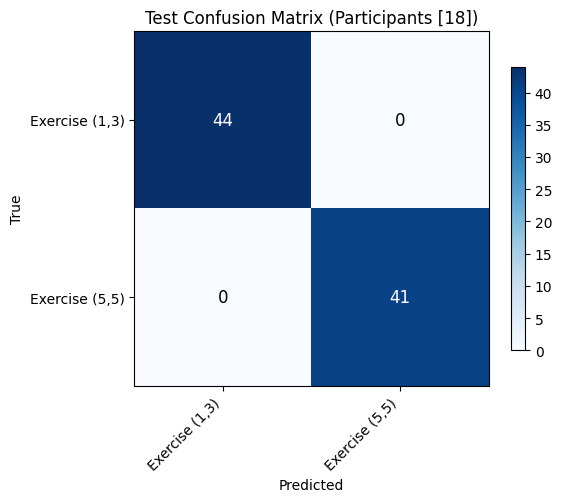


Test Classification Report:
                precision    recall  f1-score   support

Exercise (1,3)     1.0000    1.0000    1.0000        44
Exercise (5,5)     1.0000    1.0000    1.0000        41

      accuracy                         1.0000        85
     macro avg     1.0000    1.0000    1.0000        85
  weighted avg     1.0000    1.0000    1.0000        85



In [ ]:
# Test set confusion matrix
class_names = ["Exercise (1,3)", "Exercise (5,5)"]
cm_test = confusion_matrix(y_test, test_preds)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm_test, cmap="Blues")
ax.set_xticks(range(NUM_CLASSES))
ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        ax.text(j, i, f"{cm_test[i, j]}", ha="center", va="center",
                color="white" if cm_test[i, j] > cm_test.max() / 2 else "black",
                fontsize=12)

fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title(f"Test Confusion Matrix (Participants {TEST_GOLDEN_PARTICIPANTS})", fontsize=12)
plt.tight_layout()
plt.show()

print("\nTest Classification Report:")
print(classification_report(y_test, test_preds,
                            target_names=class_names, digits=4))

---
## 11. Save / Load Model

In [ ]:
# Save the test-evaluated model (trained on all Train data)
save_path = os.path.join(BASE_PATH, f"MyoGym_{SAMPLING_RATE}Hz_{CHANNEL_MODE}.pt")
torch.save(test_model.state_dict(), save_path)
print(f"Model saved to: {save_path}")

Model saved to: /content/drive/MyDrive/Spring 2026/Wearable Health Technologies/1A Activity Recognition/Data & Code & Resources/MyoGym Model/MyoGym_20Hz_accel_only.pt


In [ ]:
# Load for inference
loaded_model = CNNResBiGRU(
    in_channels=NUM_IMU_CHANNELS,
    num_classes=NUM_CLASSES,
    conv_filters=CONV_FILTERS,
).to(DEVICE)
loaded_model.load_state_dict(torch.load(save_path, map_location=DEVICE))
loaded_model.eval()

# Predict on a single window
sample = torch.FloatTensor(X_test[:1]).to(DEVICE)
with torch.no_grad():
    logits = loaded_model(sample)
    probs = torch.softmax(logits, dim=1)
    pred = logits.argmax(1).item()

label_names = {0: "Exercise (1,3)", 1: "Exercise (5,5)"}
print(f"Predicted: {label_names[pred]}")
print(f"Probabilities: {dict(zip(label_names.values(), probs[0].cpu().numpy().round(4)))}")

Predicted: Exercise (5,5)
Probabilities: {'Exercise (1,3)': np.float32(0.0035), 'Exercise (5,5)': np.float32(0.9965)}


---
## 12. Visual Inspection: Ground Truth vs Predictions (LOSO)

In [ ]:
# ============================================================
# Visual Inspection: Ground Truth vs Predictions (LOSO)
# ============================================================
# Uses the per-fold predictions already collected by run_loso,
# so no retraining and no risk of using mismatched hyperparameters.

fold_data = []
for i, p in enumerate(results["participant"]):
    fold_data.append({
        "participant": p,
        "y_true": np.asarray(results["fold_y_true"][i]),
        "y_pred": np.asarray(results["fold_y_pred"][i]),
    })
print(f"Loaded {len(fold_data)} folds from existing LOSO results.")

Loaded 18 folds from existing LOSO results.


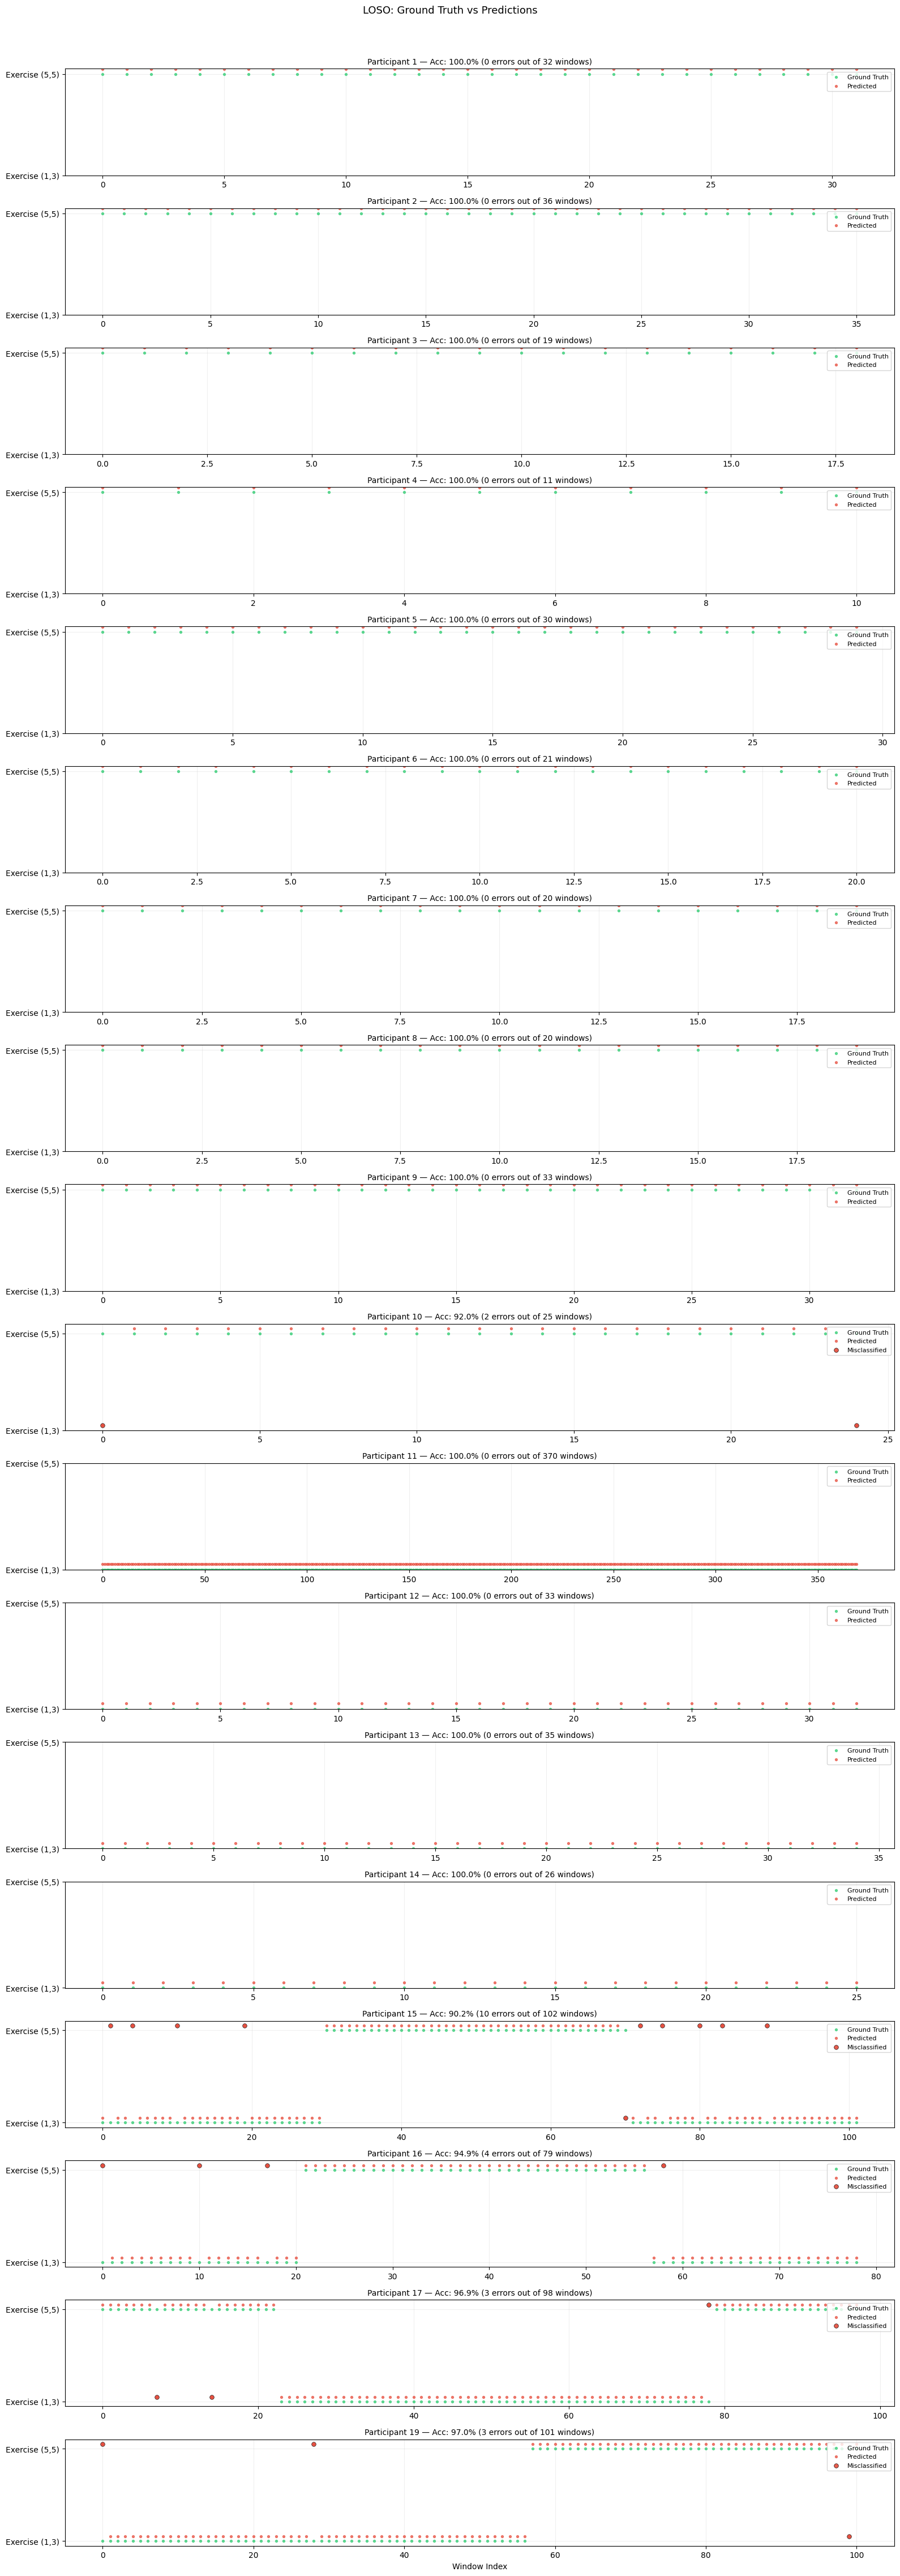

In [ ]:
n_folds = len(fold_data)
fig, axes = plt.subplots(n_folds, 1, figsize=(16, 2.5 * n_folds), sharex=False)
if n_folds == 1:
    axes = [axes]

for ax, fd in zip(axes, fold_data):
    windows = np.arange(len(fd["y_true"]))

    # Plot ground truth and predictions slightly offset so both are visible
    ax.scatter(windows, fd["y_true"], c="#2ecc71", s=8, alpha=0.7, label="Ground Truth", zorder=2)
    ax.scatter(windows, fd["y_pred"] + 0.05, c="#e74c3c", s=8, alpha=0.7, label="Predicted", zorder=2)

    # Highlight mismatches
    mismatches = fd["y_true"] != fd["y_pred"]
    if mismatches.any():
        ax.scatter(windows[mismatches], fd["y_pred"][mismatches] + 0.05,
                   c="#e74c3c", s=30, edgecolors="black", linewidths=0.5,
                   alpha=0.9, zorder=3, label="Misclassified")

    acc = accuracy_score(fd["y_true"], fd["y_pred"])
    n_wrong = mismatches.sum()
    ax.set_title(f"Participant {fd['participant']} — Acc: {acc*100:.1f}% "
                 f"({n_wrong} errors out of {len(fd['y_true'])} windows)", fontsize=10)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["Exercise (1,3)", "Exercise (5,5)"])
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True, alpha=0.2)

axes[-1].set_xlabel("Window Index")
fig.suptitle("LOSO: Ground Truth vs Predictions", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

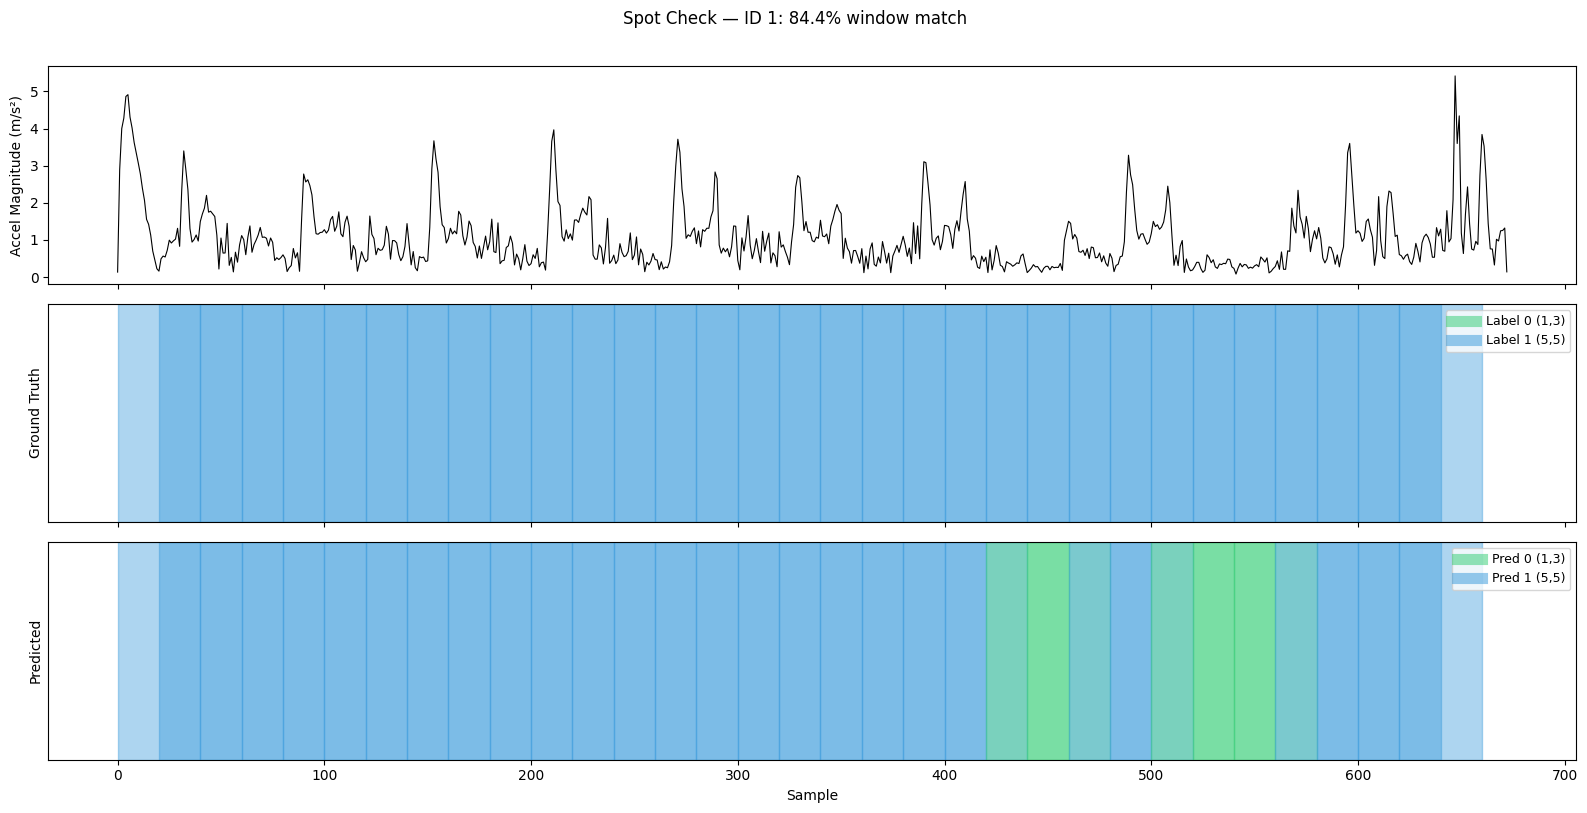

In [ ]:
# Spot-check the FINAL trained model (loaded_model from cell 37) on a
# specific ID. The final model was trained on all train participants and
# normalized with final_scaler, so we apply the same pipeline here.

spot_participant = sorted(np.unique(participants_train))[0]
spot_ids = df_filtered[df_filtered["participant"] == spot_participant]["ID"].unique()
spot_id = spot_ids[0]

spot_df = df_filtered[df_filtered["ID"] == spot_id].reset_index(drop=True)
spot_imu_raw = spot_df[IMU_COLS].values.astype(np.float64)
spot_labels  = spot_df["label"].values

# Same preprocessing as training: denoise per ID, segment, normalize with final_scaler
spot_imu_denoised = pp.denoise(spot_imu_raw)
spot_windows, spot_wlabels = pp.segment_single(spot_imu_denoised, spot_labels)
spot_X_raw = np.array(spot_windows, dtype=np.float32)
spot_X     = final_scaler.transform(spot_X_raw)
spot_y     = np.array(spot_wlabels, dtype=np.int64)

loaded_model.eval()
with torch.no_grad():
    spot_preds = loaded_model(torch.FloatTensor(spot_X).to(DEVICE)).argmax(1).cpu().numpy()

# (rest of plotting code is unchanged — uses spot_imu_denoised for the
#  magnitude plot, spot_y for ground truth, spot_preds for predictions)
fig, axes = plt.subplots(3, 1, figsize=(16, 8), sharex=True)

mag = np.sqrt(spot_imu_denoised[:, 0]**2
            + spot_imu_denoised[:, 1]**2
            + spot_imu_denoised[:, 2]**2)
mag_label = {
    "accel_AND_gyro": "Accel Magnitude (m/s²)",
    "accel_only":     "Accel Magnitude (m/s²)",
    "gyro_only":      "Gyro Magnitude (°/s)",
}[CHANNEL_MODE]
axes[0].plot(mag, color="black", linewidth=0.8)
axes[0].set_ylabel(mag_label)

colors_map = {0: "#2ecc71", 1: "#3498db"}
label_names_short = {0: "(1,3)", 1: "(5,5)"}

for i, lbl in enumerate(spot_y):
    start = i * pp.step_size
    end   = start + pp.window_size
    axes[1].axvspan(start, end, alpha=0.4, color=colors_map[lbl])
axes[1].set_ylabel("Ground Truth")
axes[1].set_yticks([])
for lbl, color in colors_map.items():
    axes[1].plot([], [], color=color, linewidth=8, alpha=0.5,
                 label=f"Label {lbl} {label_names_short[lbl]}")
axes[1].legend(loc="upper right", fontsize=9)

for i, pred in enumerate(spot_preds):
    start = i * pp.step_size
    end   = start + pp.window_size
    axes[2].axvspan(start, end, alpha=0.4, color=colors_map[pred])
axes[2].set_ylabel("Predicted")
axes[2].set_xlabel("Sample")
axes[2].set_yticks([])
for lbl, color in colors_map.items():
    axes[2].plot([], [], color=color, linewidth=8, alpha=0.5,
                 label=f"Pred {lbl} {label_names_short[lbl]}")
axes[2].legend(loc="upper right", fontsize=9)

match_pct = (spot_y == spot_preds).mean() * 100
fig.suptitle(f"Spot Check — ID {spot_id}: {match_pct:.1f}% window match",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

---
## 13. Child Class Inference: Baseline (Before Fine-Tuning)

The model was trained on parent classes **(1,3) Arm Curls** and **(5,5) Bench Press**
from `golden_dataset`.

Now we load **`OurData`**, extract all exercise child classes (every pair
except 1,3 and 5,5), and test whether the trained model correctly classifies them
by their parent class — i.e., does an Incline Bench Press (5,6) still get classified
as Bench Press?

In [ ]:
# ============================================================
# Load OurData and preprocess (matches the training pipeline exactly)
# ============================================================

OUR_DATA_PATH = os.path.join(BASE_PATH, f"data/OurData_v5_scaled_{SAMPLING_RATE}Hz.csv")
df_our = pd.read_csv(OUR_DATA_PATH)


ACCEL_COLS = ["x_accel", "y_accel", "z_accel"]
if "scaled" in OUR_DATA_PATH.lower() or df_our.attrs.get("accel_in_ms2", False):
    print("Skipping G→m/s² conversion (already in m/s²).")
else:
    print("Converting OurData acceleration from G's to m/s²...")
    df_our[ACCEL_COLS] = df_our[ACCEL_COLS] * 9.81
    df_our.attrs["accel_in_ms2"] = True

print(f"OurData: {df_our.shape[0]:,} rows, {df_our.shape[1]} columns")
print(f"Participants: {sorted(df_our['participant'].unique())}")

all_pairs_our = df_our.groupby(["parent", "child"]).size().reset_index(name="rows")
print(f"\nAll (parent, child) pairs in OurData:")
print(all_pairs_our.to_string(index=False))

parentclass_pairs = set(map(tuple, KEEP_PAIRS))
childclass_pairs = [(int(row["parent"]), int(row["child"]))
                    for _, row in all_pairs_our.iterrows()
                    if (row["parent"], row["child"]) not in parentclass_pairs]

print(f"\nParent class pairs (used for model training): {sorted(parentclass_pairs)}")
print(f"Child class pairs (unseen by model):           {sorted(childclass_pairs)}")

childclass_mask = pd.Series(False, index=df_our.index)
for p, c in childclass_pairs:
    childclass_mask |= (df_our["parent"] == p) & (df_our["child"] == c)
df_childclasses = df_our[childclass_mask].copy().reset_index(drop=True)
df_childclasses["label"] = df_childclasses["parent"].map(LABEL_MAP)

print(f"\nChildclass data: {len(df_childclasses):,} rows, "
      f"{df_childclasses['ID'].nunique()} IDs")

# Per-ID denoise + segment, then normalize with final_scaler (the
# train-only scaler from cell 14). Tracks (parent,child,participant,id)
# alongside windows so we can do per-pair analysis later.
print("\nPreprocessing childclass data (per-ID denoise → segment → normalize)...")
all_X, all_y, all_parts, all_pair_labels, all_ids = [], [], [], [], []

for uid in df_childclasses["ID"].unique():
    subset = df_childclasses[df_childclasses["ID"] == uid]
    if len(subset) < pp.window_size:
        print(f"  ID {uid}: {len(subset)} rows — too short, skipping")
        continue

    imu = subset[IMU_COLS].values.astype(np.float64)
    imu = pp.denoise(imu)   # per-ID denoise

    labels      = subset["label"].values
    pair        = (int(subset["parent"].iloc[0]), int(subset["child"].iloc[0]))
    participant = int(subset["participant"].iloc[0])

    windows, window_labels = pp.segment_single(imu, labels)
    all_X.extend(windows)
    all_y.extend(window_labels)
    all_parts.extend([participant] * len(windows))
    all_pair_labels.extend([pair] * len(windows))
    all_ids.extend([int(uid)] * len(windows))

X_var_all_raw = np.array(all_X, dtype=np.float32)
X_var_all     = final_scaler.transform(X_var_all_raw)   # train-only scaler
y_var_all     = np.array(all_y, dtype=np.int64)
parts_var_all = np.array(all_parts)
pairs_var_all = np.array(all_pair_labels)
ids_var_all   = np.array(all_ids)

print(f"\nSegmented: {X_var_all.shape[0]} windows total")
print(f"  Label 0 (Arm Curl childclasses):    {(y_var_all == 0).sum()}")
print(f"  Label 1 (Bench Press childclasses): {(y_var_all == 1).sum()}")

Skipping G→m/s² conversion (already in m/s²).
OurData: 52,828 rows, 11 columns
Participants: [np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19)]

All (parent, child) pairs in OurData:
 parent  child  rows
      1      1  5273
      1      2  5595
      1      3  5535
      1      4  5697
      5      5  4356
      5      6  5247
      5      7  4529
      5      8  5629
      5      9  5425
      5     10  5542

Parent class pairs (used for model training): [(1, 3), (5, 5)]
Child class pairs (unseen by model):           [(1, 1), (1, 2), (1, 4), (5, 6), (5, 7), (5, 8), (5, 9), (5, 10)]

Childclass data: 42,937 rows, 78 IDs

Preprocessing childclass data (per-ID denoise → segment → normalize)...

Segmented: 2028 windows total
  Label 0 (Arm Curl childclasses):    785
  Label 1 (Bench Press childclasses): 1243


In [ ]:
# ============================================================
# Baseline inference on ALL childclass data (before any fine-tuning)
# ============================================================

loaded_model.eval()
with torch.no_grad():
    logits = loaded_model(torch.FloatTensor(X_var_all).to(DEVICE))
    baseline_preds = logits.argmax(1).cpu().numpy()
    baseline_probs = torch.softmax(logits, dim=1).cpu().numpy()

# Per-pair results
baseline_results = []
unique_pairs = sorted(set(map(tuple, pairs_var_all.tolist())))

for pair in unique_pairs:
    p, c = pair
    mask = (pairs_var_all[:, 0] == p) & (pairs_var_all[:, 1] == c)
    preds_pair = baseline_preds[mask]
    expected = LABEL_MAP[p]

    acc = (preds_pair == expected).mean()
    mean_conf = baseline_probs[mask, expected].mean()

    baseline_results.append({
        "parent": p, "child": c,
        "expected": "Arm Curl" if expected == 0 else "Bench Press",
        "n_windows": int(mask.sum()),
        "accuracy": acc,
        "mean_confidence": mean_conf,
        "pred_arm_curl": int((preds_pair == 0).sum()),
        "pred_bench_press": int((preds_pair == 1).sum()),
    })

print("Baseline inference complete.")

Baseline inference complete.


In [ ]:
# ============================================================
# Baseline summary table
# ============================================================

var_df = pd.DataFrame(baseline_results)
var_df["pair"] = var_df.apply(lambda r: f"({int(r['parent'])},{int(r['child'])})", axis=1)
var_df = var_df[["pair", "expected", "n_windows",
                 "pred_arm_curl", "pred_bench_press", "accuracy", "mean_confidence"]]
var_df.columns = ["(Parent,Child)", "Expected Class", "Windows",
                  "Pred Arm Curl", "Pred Bench Press", "Accuracy", "Mean Conf"]

print("Baseline Childclass Inference Results (BEFORE fine-tuning)")
print("=" * 85)
print("Model trained on: (1,3) Arm Curls  +  (5,5) Bench Press")
print("Testing on: unseen exercise variations from OurData\n")
display(var_df.round(4))

# Aggregated by expected class
print("\n--- Aggregated by expected class ---")
for expected in ["Arm Curl", "Bench Press"]:
    subset = var_df[var_df["Expected Class"] == expected]
    if len(subset) == 0:
        continue
    total_windows = subset["Windows"].sum()
    correct = subset["Pred Arm Curl"].sum() if expected == "Arm Curl" else subset["Pred Bench Press"].sum()
    overall_acc = correct / total_windows if total_windows > 0 else 0
    print(f"  {expected} childclasses: {overall_acc*100:.2f}% correct "
          f"({int(correct)}/{int(total_windows)} windows across {len(subset)} childclass pairs)")

Baseline Childclass Inference Results (BEFORE fine-tuning)
Model trained on: (1,3) Arm Curls  +  (5,5) Bench Press
Testing on: unseen exercise variations from OurData



,"(Parent,Child)",Expected Class,Windows,Pred Arm Curl,Pred Bench Press,Accuracy,Mean Conf
0,"(1,1)",Arm Curl,251,203,48,0.8088,0.7802
1,"(1,2)",Arm Curl,264,262,2,0.9924,0.9839
2,"(1,4)",Arm Curl,270,65,205,0.2407,0.2534
3,"(5,6)",Bench Press,247,23,224,0.9069,0.8919
4,"(5,7)",Bench Press,210,13,197,0.9381,0.9179
5,"(5,8)",Bench Press,266,57,209,0.7857,0.7756
6,"(5,9)",Bench Press,257,32,225,0.8755,0.8736
7,"(5,10)",Bench Press,263,40,223,0.8479,0.8190



--- Aggregated by expected class ---
  Arm Curl childclasses: 67.52% correct (530/785 windows across 3 childclass pairs)
  Bench Press childclasses: 86.73% correct (1078/1243 windows across 5 childclass pairs)


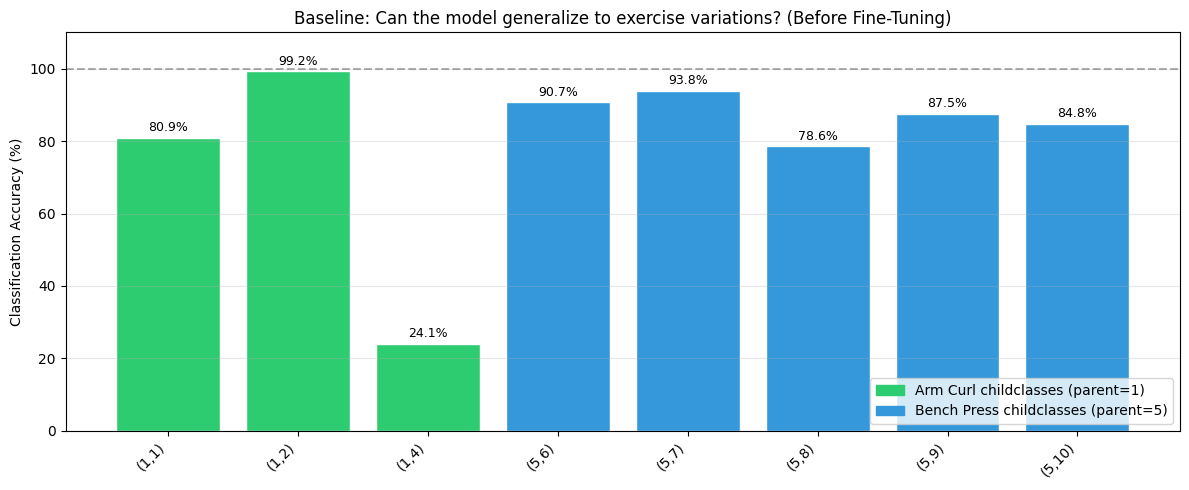

In [ ]:
# ============================================================
# Baseline bar chart
# ============================================================

fig, ax = plt.subplots(figsize=(12, 5))

colors = ["#2ecc71" if row["Expected Class"] == "Arm Curl" else "#3498db"
          for _, row in var_df.iterrows()]
bars = ax.bar(range(len(var_df)), var_df["Accuracy"] * 100, color=colors, edgecolor="white")

ax.set_xticks(range(len(var_df)))
ax.set_xticklabels(var_df["(Parent,Child)"], rotation=45, ha="right")
ax.set_ylabel("Classification Accuracy (%)")
ax.set_title("Baseline: Can the model generalize to exercise variations? (Before Fine-Tuning)")
ax.set_ylim(0, 110)
ax.axhline(y=100, color="black", linestyle="--", alpha=0.3)

for bar, acc in zip(bars, var_df["Accuracy"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f"{acc*100:.1f}%", ha="center", va="bottom", fontsize=9)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="#2ecc71", label="Arm Curl childclasses (parent=1)"),
    Patch(color="#3498db", label="Bench Press childclasses (parent=5)"),
], loc="lower right")

ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

---
## 14. Progressive Fine-Tuning on Exercise Childclasss

### The Situation

Our model was trained on just two exercises: (1,3) Barbell Arm Curls (i.e. parent class = Arm Curl) and (5,5) Flat Barbell Bench Press (i.e. parent class = Bench Press). But in the real world, people don't do exactly those two movements — they do variations. Someone might do an Incline Barebell Bench Press (5,6), Preacher Curls (1,2), or Decline Barbell Bench Press (5,7). These are all still "bench presses" or "arm curls" at the parent-class level, but the specific movement patterns look different in the IMU data.

In Section 13, we tested the trained model on all these childclasses without any additional training and measured how well it generalizes. For childclasses that happen to look similar to the parentclass exercises, the model will classify them correctly just from what it already learned. For childclasses that look different enough, it may struggle.

### The Question We're Answering

If the model doesn't generalize well to some childclasses, **how much childclass data would we need to show it before it starts classifying them correctly?** This is practically important: collecting IMU data is expensive and time-consuming, and knowing whether we need 5%, 20%, or 100% of a full childclass dataset tells us how much effort to budget for future data collection.


### Why a Lower Learning Rate

When we originally trained the model, we used a learning rate found by our hyperparameter sweep — the rate that worked best for learning from scratch. For fine-tuning, we deliberately use a learning rate **ten times smaller**. The model already knows the fundamental difference between arm curls and bench presses; we don't want to overwrite that knowledge. A smaller learning rate means each gradient update nudges the weights only slightly, gently expanding what the model knows rather than rebuilding it. If we used the original learning rate, large weight updates could destroy the original learned features — a phenomenon called **catastrophic forgetting**, where fine-tuning on new data causes a model to forget what it previously knew.

### The Progressive Setup

We want a curve, not a single number. So we repeat the fine-tuning process at different sample sizes, measured as the number of IDs per (parent, child) pair that the model is shown. Each point on this curve tells us "if you gave the model this many IDs per childclass, here's the accuracy it would reach." We can then look at the curve and see where it plateaus — that's the sweet spot between data collection effort and accuracy gain. (Why IDs and not percentages? See the next section.)

### Why Each Percentage Step Is Independent

At the start of each step, we reload the original trained weights — for example, the 2-IDs/pair run does not benefit from any training that happened during the 1-ID/pair run. This is critical for making the per-step values directly comparable. If we kept accumulating training across steps, the 2-IDs/pair run would have effectively seen 1+2 = 3 IDs/pair of data, and its accuracy wouldn't really tell us what 2 IDs of data achieves.


### What "Stratified ID Sampling" Means

There are two important details in how we sample. First, we sample **whole IDs, not individual windows**. Each ID in our data represents a single complete exercise set — roughly 10 reps performed back-to-back. If we randomly pulled individual windows, we'd get disconnected fragments: window 3 from one set, window 17 from another, window 8 from a third. The model would see choppy snippets instead of coherent movement patterns. By sampling at the ID level, every sampled unit is a complete, uninterrupted set of an exercise.

Second, we sample in a **stratified** way at the (parent, child) pair level. Our childclass data contains multiple specific exercises — (1,1), (1,2), (1,4) for arm curl childclasses and (5,6) through (5,10) for bench press childclasses. If we just randomly grabbed IDs, a small sample might happen to pull only Incline Bench Press and Decline Bench Press while missing childclasses of arm curls entirely. The model would then only learn about the childclasses it saw, and results would be misleading. Stratified sampling by pair means that for every unique (parent, child) combination, we separately sample the same percentage of its IDs and then combine them. For example, at 25%, we pull 25% of (1,1) IDs AND 25% of (1,2) IDs AND 25% of (1,4) IDs AND so on — guaranteeing that every childclass is proportionally represented at every step, no matter how small the percentage.

### The Split: Who We Fine-Tune On vs Evaluate On

Our childclass data comes from five participants (15, 16, 17, 18, 19). Participant 15 is our held-out test participant — they've never appeared in any training or validation up to this point, and we want to keep it that way. So we use childclasses from **participants 16, 17, 18, and 19 for fine-tuning**, and childclasses from **participant 15 for testing only**. This way, when we report that "after fine-tuning on 25% of childclass data, the model reaches X% accuracy on childclasses," that X% reflects genuine generalization to an unseen person — not inflated numbers from testing on data the model already saw during fine-tuning.

### Watching for Catastrophic Forgetting

At every step of additional childclass fine-tuning data, in addition to measuring how well the fine-tuned model performs on childclasses, we also re-evaluate it on the original parentclass test data from the golden_dataset. If fine-tuning is going well, parentclass accuracy should stay roughly the same as before. If parentclass accuracy starts dropping, it means fine-tuning is eroding the model's original knowledge of the parentclass exercises — catastrophic forgetting in action. The two accuracy curves plotted side by side (childclass accuracy hopefully going up, parentclass accuracy hopefully staying flat) tell the full story of whether fine-tuning is a net win.

In [ ]:
# ============================================================
# Split childclass data: fine-tune vs test (by participant)
# ============================================================

ft_mask = ~np.isin(parts_var_all, TEST_OURDATA_PARTICIPANTS)
eval_mask = np.isin(parts_var_all, TEST_OURDATA_PARTICIPANTS)

X_var_ft     = X_var_all[ft_mask]
y_var_ft     = y_var_all[ft_mask]
pairs_var_ft = pairs_var_all[ft_mask]
ids_var_ft   = ids_var_all[ft_mask]

X_var_eval     = X_var_all[eval_mask]
y_var_eval     = y_var_all[eval_mask]
pairs_var_eval = pairs_var_all[eval_mask]
ids_var_eval   = ids_var_all[eval_mask]

print("Childclass data split:")
print(f"  Fine-tune set: {len(X_var_ft)} windows "
      f"(participants {sorted(set(parts_var_all[ft_mask].tolist()))})")
print(f"    Label 0 (Arm Curl):    {(y_var_ft == 0).sum()}")
print(f"    Label 1 (Bench Press): {(y_var_ft == 1).sum()}")
print(f"\n  Eval set: {len(X_var_eval)} windows "
      f"(participant {sorted(set(parts_var_all[eval_mask].tolist()))})")
print(f"    Label 0 (Arm Curl):    {(y_var_eval == 0).sum()}")
print(f"    Label 1 (Bench Press): {(y_var_eval == 1).sum()}")

# Show eval set pair breakdown so we know what we're measuring
print(f"\n  Eval set per-pair breakdown:")
eval_pairs = sorted(set(map(tuple, pairs_var_eval.tolist())))
for p, c in eval_pairs:
    mask = (pairs_var_eval[:, 0] == p) & (pairs_var_eval[:, 1] == c)
    expected = "Arm Curl" if LABEL_MAP[p] == 0 else "Bench Press"
    print(f"    ({p},{c}) {expected}: {mask.sum()} windows")


# ---- Helper function: evaluate a model on childclass data ----
def evaluate_childclasses(model, X, y, pairs, device):
    """
    Run inference, return overall metrics and per-pair accuracy breakdown.
    """
    model.eval()
    with torch.no_grad():
        logits = model(torch.FloatTensor(X).to(device))
        preds = logits.argmax(1).cpu().numpy()

    overall_acc = accuracy_score(y, preds)
    overall_f1  = f1_score(y, preds, average="macro", zero_division=0)

    per_pair = {}
    for pair in sorted(set(map(tuple, pairs.tolist()))):
        p, c = pair
        mask = (pairs[:, 0] == p) & (pairs[:, 1] == c)
        if mask.sum() == 0:
            continue
        expected = LABEL_MAP[p]
        pair_preds = preds[mask]
        per_pair[(p, c)] = {
            "accuracy": (pair_preds == expected).mean(),
            "n_windows": int(mask.sum()),
            "expected": "Arm Curl" if expected == 0 else "Bench Press",
        }

    return {"overall_acc": overall_acc, "overall_f1": overall_f1,
            "preds": preds, "per_pair": per_pair}

Childclass data split:
  Fine-tune set: 1500 windows (participants [16, 17, 18, 19])
    Label 0 (Arm Curl):    612
    Label 1 (Bench Press): 888

  Eval set: 528 windows (participant [15])
    Label 0 (Arm Curl):    173
    Label 1 (Bench Press): 355

  Eval set per-pair breakdown:
    (1,1) Arm Curl: 61 windows
    (1,2) Arm Curl: 55 windows
    (1,4) Arm Curl: 57 windows
    (5,6) Bench Press: 62 windows
    (5,7) Bench Press: 34 windows
    (5,8) Bench Press: 100 windows
    (5,9) Bench Press: 70 windows
    (5,10) Bench Press: 89 windows


### A Note on Sampling: Why We Switched from Percentages to ID Counts

Our initial approach to the progressive fine-tuning curve was to iterate through fixed percentages of the childclass data — 5%, 10%, 15%, and so on up to 100%. This seemed like the natural way to ask "how much data does the model need?" because it gave us nice round numbers to plot and report.

After running the first version, however, we noticed a large jump in childclass accuracy between the 50% and 75% steps — the curve climbed from roughly 76% to 94% in a single increment, with no intermediate data points to show what was happening in between. The natural instinct was to add finer percentage steps (55%, 60%, 65%, 70%) to characterize that transition more precisely.

That's when we hit a limitation of the percentage-based approach. Each childclass pair in our fine-tune set only contains 8 IDs. When we apply a percentage to such a small pool, many different percentage values round to the same integer number of IDs. For example, with 8 IDs in a pair:

- 50% → round(4.0) = 4 IDs
- 55% → round(4.4) = 4 IDs (same as 50%)
- 60% → round(4.8) = 5 IDs
- 65% → round(5.2) = 5 IDs (same as 60%)

So adding a step at "55%" wouldn't actually show us anything new — it would re-run the exact same sample size as 50%, and the only difference would be random sampling variance. Between 50% and 75%, there are really only two meaningful transitions: 4 IDs → 5 IDs, and 5 IDs → 6 IDs. The percentage axis was hiding this discreteness and creating the illusion of a continuous sweep.

The cleaner approach — the one we've now adopted — is to iterate directly over the quantity the model actually sees: **the number of IDs per childclass pair**. We start at 1 ID per pair, then 2, then 3, all the way up to the maximum available.

In [ ]:
# ============================================================
# Progressive fine-tuning loop (iterating by IDs per pair)
# ============================================================

FINE_TUNE_LR     = best_lr / 10    # gentle updates to preserve learned features
FINE_TUNE_EPOCHS = 20              # fixed epoch count per step

# Determine how many IDs each childclass pair has in the fine-tune set
pair_id_counts = {}
for pair in sorted(set(map(tuple, pairs_var_ft.tolist()))):
    p, c = pair
    pair_mask = (pairs_var_ft[:, 0] == p) & (pairs_var_ft[:, 1] == c)
    pair_id_counts[pair] = len(np.unique(ids_var_ft[pair_mask]))

max_ids_per_pair = max(pair_id_counts.values())
total_fine_tune_ids = sum(pair_id_counts.values())

print(f"Fine-tune set IDs per pair:")
for pair, n in sorted(pair_id_counts.items()):
    print(f"  ({pair[0]},{pair[1]}): {n} IDs")
print(f"Max IDs per pair: {max_ids_per_pair}")
print(f"Total fine-tune IDs: {total_fine_tune_ids}\n")

ft_rng = np.random.default_rng(SEED)
ft_curve = []

# Track the best-performing fine-tuned model across all steps
best_ft_acc = -1
best_ft_state = None
best_ft_n_ids = None

# Baseline eval (before any fine-tuning)
baseline_eval = evaluate_childclasses(loaded_model, X_var_eval, y_var_eval,
                                  pairs_var_eval, DEVICE)
print(f"Baseline childclass eval accuracy (no fine-tuning): "
      f"{baseline_eval['overall_acc']*100:.2f}%\n")

# Iterate: 1 ID per pair, 2 IDs per pair, ..., up to max
for n_ids_per_pair in range(1, max_ids_per_pair + 1):
    print(f"\n{'='*60}")
    print(f"  Fine-tuning with {n_ids_per_pair} ID(s) per pair "
          f"(lr={FINE_TUNE_LR:.1e}, epochs={FINE_TUNE_EPOCHS})")
    print(f"{'='*60}")

    # ---- Stratified ID sampling: take n_ids_per_pair from each (parent, child) ----
    # If a pair has fewer than n_ids_per_pair IDs available, take all of them
    sampled_ids = []
    for pair in sorted(pair_id_counts.keys()):
        p, c = pair
        pair_mask = (pairs_var_ft[:, 0] == p) & (pairs_var_ft[:, 1] == c)
        pair_ids = np.unique(ids_var_ft[pair_mask])
        n_to_sample = min(n_ids_per_pair, len(pair_ids))
        sampled = ft_rng.choice(pair_ids, n_to_sample, replace=False)
        sampled_ids.extend(sampled.tolist())

    # Compute the actual percentage of the fine-tune set this represents
    pct_actual = len(sampled_ids) / total_fine_tune_ids * 100

    # Pull all windows belonging to sampled IDs
    sample_mask = np.isin(ids_var_ft, sampled_ids)
    X_sub = X_var_ft[sample_mask]
    y_sub = y_var_ft[sample_mask]

    print(f"  Sampled {len(sampled_ids)} IDs ({pct_actual:.1f}% of fine-tune set) "
          f"→ {len(X_sub)} windows "
          f"(label 0: {(y_sub == 0).sum()}, label 1: {(y_sub == 1).sum()})")

    # ---- Reload original trained weights (independent from previous steps) ----
    model = CNNResBiGRU(
        in_channels=NUM_IMU_CHANNELS, num_classes=NUM_CLASSES, conv_filters=CONV_FILTERS
    ).to(DEVICE)
    model.load_state_dict(torch.load(save_path, map_location=DEVICE))

    # ---- Fine-tune ----
    optimizer = torch.optim.Adam(model.parameters(), lr=FINE_TUNE_LR)
    loss_fn = nn.CrossEntropyLoss()

    X_sub_t = torch.FloatTensor(X_sub).to(DEVICE)
    y_sub_t = torch.LongTensor(y_sub).to(DEVICE)
    train_dl = DataLoader(TensorDataset(X_sub_t, y_sub_t),
                          batch_size=min(32, len(X_sub)), shuffle=True)

    model.train()
    for epoch in range(FINE_TUNE_EPOCHS):
        total_loss, n = 0.0, 0
        for xb, yb in train_dl:
            optimizer.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            n += 1
        if (epoch + 1) % 5 == 0:
            print(f"    Epoch {epoch+1:3d}  loss={total_loss/n:.4f}")

    # ---- Evaluate on childclass eval set (held-out participant) ----
    var_eval = evaluate_childclasses(model, X_var_eval, y_var_eval,
                                 pairs_var_eval, DEVICE)

    # ---- Evaluate on parentclass test set (check for catastrophic forgetting) ----
    model.eval()
    with torch.no_grad():
        parentclass_preds = model(
            torch.FloatTensor(X_test).to(DEVICE)
        ).argmax(1).cpu().numpy()
    parentclass_acc = accuracy_score(y_test, parentclass_preds)
    parentclass_f1  = f1_score(y_test, parentclass_preds, average="macro", zero_division=0)

    ft_curve.append({
        "n_ids_per_pair": n_ids_per_pair,
        "n_ids_total": len(sampled_ids),
        "pct": pct_actual,
        "n_windows": len(X_sub),
        "childclass_acc": var_eval["overall_acc"],
        "childclass_f1":  var_eval["overall_f1"],
        "parentclass_acc": parentclass_acc,
        "parentclass_f1":  parentclass_f1,
        "per_pair": var_eval["per_pair"],
    })

    # ---- Save this model's weights if it's the best so far ----
    if var_eval["overall_acc"] > best_ft_acc:
        best_ft_acc = var_eval["overall_acc"]
        best_ft_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        best_ft_n_ids = n_ids_per_pair
        print(f"  ★ New best childclass accuracy — saving state")

    print(f"\n  Childclass eval acc:  {var_eval['overall_acc']*100:.2f}%  "
          f"F1: {var_eval['overall_f1']*100:.2f}%")
    print(f"  Core test acc:     {parentclass_acc*100:.2f}%  "
          f"F1: {parentclass_f1*100:.2f}%  ← watch for degradation")

print("\n\n✓ Progressive fine-tuning complete!")

# ---- Save the best fine-tuned model to disk ----
ft_save_path = os.path.join(BASE_PATH, f"MyoGym_{SAMPLING_RATE}Hz_{CHANNEL_MODE}_finetuned.pt")
torch.save(best_ft_state, ft_save_path)
print(f"\nBest fine-tuned model saved:")
print(f"  IDs per pair: {best_ft_n_ids}")
print(f"  Childclass eval accuracy: {best_ft_acc*100:.2f}%")
print(f"  Path: {ft_save_path}")

Fine-tune set IDs per pair:
  (1,1): 6 IDs
  (1,2): 8 IDs
  (1,4): 8 IDs
  (5,6): 8 IDs
  (5,7): 8 IDs
  (5,8): 8 IDs
  (5,9): 8 IDs
  (5,10): 8 IDs
Max IDs per pair: 8
Total fine-tune IDs: 62

Baseline childclass eval accuracy (no fine-tuning): 64.20%


  Fine-tuning with 1 ID(s) per pair (lr=1.0e-04, epochs=20)
  Sampled 8 IDs (12.9% of fine-tune set) → 235 windows (label 0: 93, label 1: 142)
    Epoch   5  loss=0.3195
    Epoch  10  loss=0.1759
    Epoch  15  loss=0.1122
    Epoch  20  loss=0.1122
  ★ New best childclass accuracy — saving state

  Childclass eval acc:  80.30%  F1: 72.28%
  Core test acc:     98.82%  F1: 98.82%  ← watch for degradation

  Fine-tuning with 2 ID(s) per pair (lr=1.0e-04, epochs=20)
  Sampled 16 IDs (25.8% of fine-tune set) → 439 windows (label 0: 191, label 1: 248)
    Epoch   5  loss=0.1900
    Epoch  10  loss=0.0943
    Epoch  15  loss=0.0511
    Epoch  20  loss=0.0438
  ★ New best childclass accuracy — saving state

  Childclass eval acc:  81.25%  F1

In [ ]:
# ============================================================
# Fine-tuning results table
# ============================================================

curve_df = pd.DataFrame([{
    "IDs per Pair":     r["n_ids_per_pair"],
    "Total IDs Used":   r["n_ids_total"],
    "% of FT Set":      r["pct"],
    "Windows Used":     r["n_windows"],
    "Childclass Acc (%)":  r["childclass_acc"] * 100,
    "Childclass F1 (%)":   r["childclass_f1"] * 100,
    "Parentclass Acc (%)":     r["parentclass_acc"] * 100,
    "Parentclass F1 (%)":      r["parentclass_f1"] * 100,
} for r in ft_curve])

print("Progressive Fine-Tuning Results")
print("=" * 85)
print(f"Fine-tune LR: {FINE_TUNE_LR:.1e}  |  Epochs: {FINE_TUNE_EPOCHS}  |  "
        f"Eval participant: {sorted(set(parts_var_all[eval_mask].tolist()))}")
print(f"Baseline childclass accuracy (before fine-tuning): "
      f"{baseline_eval['overall_acc']*100:.2f}%\n")
display(curve_df.round(2))

Progressive Fine-Tuning Results
Fine-tune LR: 1.0e-04  |  Epochs: 20  |  Eval participant: [15]
Baseline childclass accuracy (before fine-tuning): 64.20%



,IDs per Pair,Total IDs Used,% of FT Set,Windows Used,Childclass Acc (%),Childclass F1 (%),Parentclass Acc (%),Parentclass F1 (%)
0,1,8,12.90,235,80.30,72.28,98.82,98.82
1,2,16,25.81,439,81.25,75.31,98.82,98.82
2,3,24,38.71,562,78.03,72.77,98.82,98.82
3,4,32,51.61,760,85.04,81.50,98.82,98.82
4,5,40,64.52,999,83.71,81.78,98.82,98.82
5,6,48,77.42,1177,72.92,71.08,98.82,98.82
6,7,55,88.71,1330,80.49,77.26,98.82,98.82
7,8,62,100.00,1500,80.68,76.80,98.82,98.82


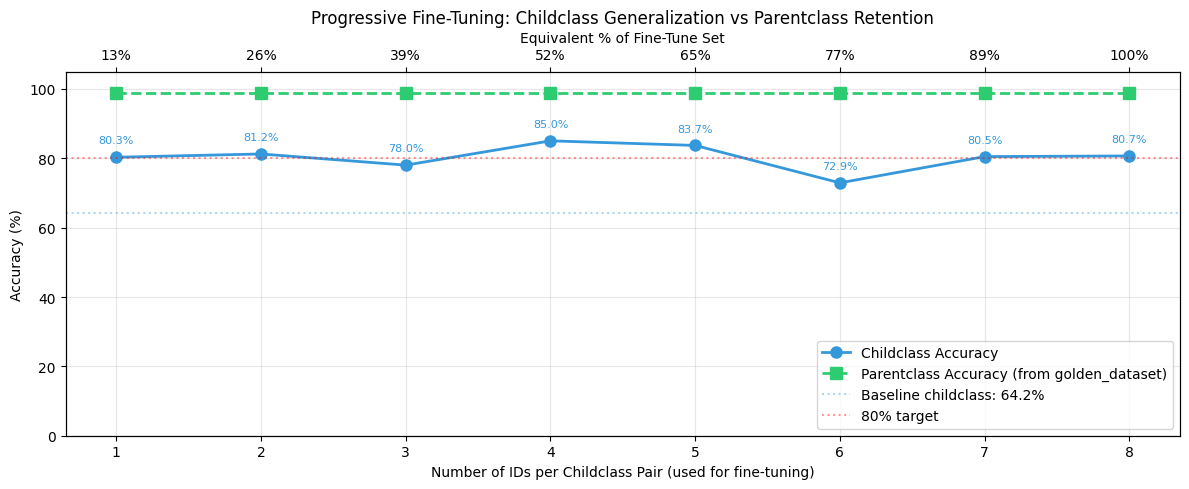

In [ ]:
# ============================================================
# Accuracy curve: childclass generalization vs parentclass retention
# ============================================================

fig, ax = plt.subplots(figsize=(12, 5))

n_ids_vals = [r["n_ids_per_pair"] for r in ft_curve]
pct_vals   = [r["pct"] for r in ft_curve]
var_accs   = [r["childclass_acc"] * 100 for r in ft_curve]
parentclass_accs  = [r["parentclass_acc"] * 100 for r in ft_curve]

# Fine-tuning curves
ax.plot(n_ids_vals, var_accs, "o-", color="#3498db", linewidth=2,
        markersize=8, label="Childclass Accuracy")
ax.plot(n_ids_vals, parentclass_accs, "s--", color="#2ecc71", linewidth=2,
        markersize=8, label="Parentclass Accuracy (from golden_dataset)")

# Reference lines
ax.axhline(y=baseline_eval["overall_acc"] * 100, color="#3498db",
           linestyle=":", alpha=0.4,
           label=f"Baseline childclass: {baseline_eval['overall_acc']*100:.1f}%")
ax.axhline(y=80, color="red", linestyle=":", alpha=0.4, label="80% target")

# Label each point with its childclass accuracy
for x, y_val in zip(n_ids_vals, var_accs):
    ax.annotate(f"{y_val:.1f}%", (x, y_val), textcoords="offset points",
                xytext=(0, 10), ha="center", fontsize=8, color="#3498db")

ax.set_xlabel("Number of IDs per Childclass Pair (used for fine-tuning)")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Progressive Fine-Tuning: Childclass Generalization vs Parentclass Retention")
ax.set_xticks(n_ids_vals)

# Secondary x-axis showing the corresponding % of fine-tune set
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks(n_ids_vals)
ax2.set_xticklabels([f"{p:.0f}%" for p in pct_vals])
ax2.set_xlabel("Equivalent % of Fine-Tune Set")

ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 105)

plt.tight_layout()
plt.show()

The green line is the **catastrophic forgetting monitor**.


At every fine-tuning step in the loop above, after fine-tuning on some percentage of OurData childclasses, the model gets re-evaluated on these original golden parentclass windows. The green line is asking: "after nudging the weights to accommodate childclasses, does the model still know how to classify the parentclass exercises it originally learned?"


The  green line sitting flat at 100% across every percentage step is the result we want. It means fine-tuning on OurData childclasses isn't degrading the model's original knowledge of (1,3) Arm Curls and (5,5) Bench Press at all — no forgetting is happening. The low fine-tuning learning rate (best_lr / 10) is doing its job of gently expanding knowledge rather than overwriting it.


If that green line had dropped to, say, 70% while the blue line climbed to 90%, that'd be catastrophic forgetting in action — we'd be gaining childclass accuracy at the cost of parentclass accuracy.

Another interesting observation:


the baseline is actually higher than several of our fine-tuned points. At those percentages, fine-tuning is making things worse on the eval set, not better.

Per-Pair Accuracy (%) Across Fine-Tuning Steps
(Baseline = before any fine-tuning)



,Pair,Expected,Baseline,1 ID/pair,2 IDs/pair,3 IDs/pair,4 IDs/pair,5 IDs/pair,6 IDs/pair,7 IDs/pair,8 IDs/pair
0,"(1,1)",Arm Curl,50.8,19.7,21.3,45.9,55.7,57.4,62.3,52.5,52.5
1,"(1,2)",Arm Curl,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
2,"(1,4)",Arm Curl,0.0,5.3,29.8,12.3,35.1,78.9,57.9,45.6,31.6
3,"(5,6)",Bench Press,95.2,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
4,"(5,7)",Bench Press,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
5,"(5,8)",Bench Press,53.0,100.0,95.0,87.0,92.0,88.0,63.0,87.0,90.0
6,"(5,9)",Bench Press,65.7,98.6,98.6,88.6,97.1,81.4,71.4,82.9,85.7
7,"(5,10)",Bench Press,68.5,100.0,94.4,86.5,94.4,74.2,56.2,79.8,84.3


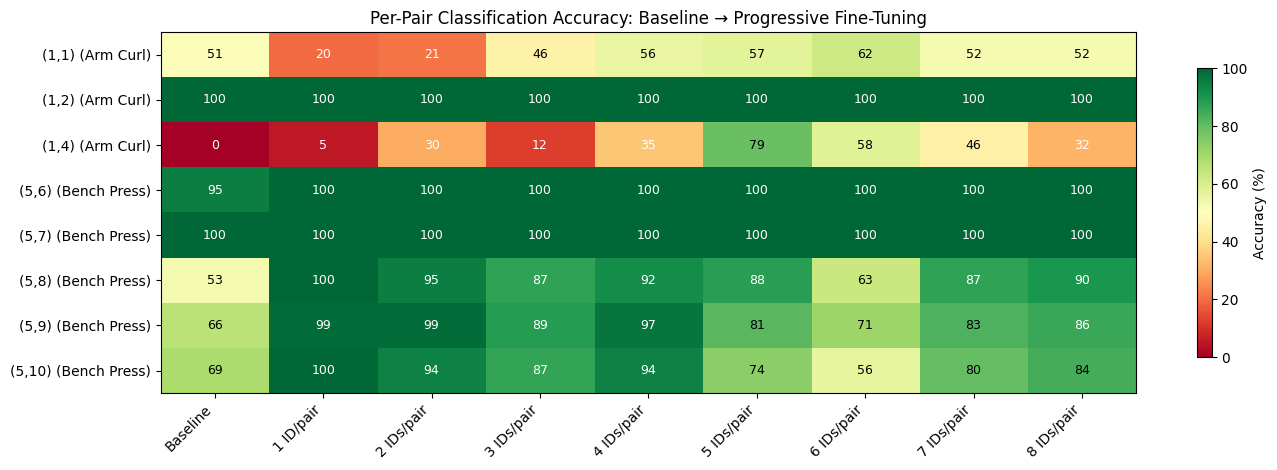

In [ ]:
# ============================================================
# Per-pair accuracy at each fine-tuning step
# ============================================================

pair_list = sorted(ft_curve[0]["per_pair"].keys())

# Build table data
rows = []
for pair in pair_list:
    p, c = pair
    expected = ft_curve[0]["per_pair"][pair]["expected"]
    row = {"Pair": f"({p},{c})", "Expected": expected}

    # Baseline (before fine-tuning)
    bl_pair = baseline_eval["per_pair"].get(pair, {})
    row["Baseline"] = bl_pair.get("accuracy", 0) * 100

    # Each fine-tuning step — keyed by IDs per pair
    for r in ft_curve:
        col_name = f"{r['n_ids_per_pair']} ID{'s' if r['n_ids_per_pair'] != 1 else ''}/pair"
        pair_data = r["per_pair"].get(pair, {})
        row[col_name] = pair_data.get("accuracy", 0) * 100

    rows.append(row)

pair_df = pd.DataFrame(rows)

print("Per-Pair Accuracy (%) Across Fine-Tuning Steps")
print("=" * 90)
print("(Baseline = before any fine-tuning)\n")
display(pair_df.round(1))

# ---- Heatmap visualization ----
step_cols = ["Baseline"] + [
    f"{r['n_ids_per_pair']} ID{'s' if r['n_ids_per_pair'] != 1 else ''}/pair"
    for r in ft_curve
]
heat_data = pair_df[step_cols].values.astype(float)
pair_labels = [f"{row['Pair']} ({row['Expected']})" for _, row in pair_df.iterrows()]

fig, ax = plt.subplots(figsize=(14, max(4, len(pair_list) * 0.6)))
im = ax.imshow(heat_data, cmap="RdYlGn", vmin=0, vmax=100, aspect="auto")

ax.set_xticks(range(len(step_cols)))
ax.set_xticklabels(step_cols, rotation=45, ha="right")
ax.set_yticks(range(len(pair_labels)))
ax.set_yticklabels(pair_labels)

for i in range(len(pair_labels)):
    for j in range(len(step_cols)):
        val = heat_data[i, j]
        color = "white" if val < 40 or val > 85 else "black"
        ax.text(j, i, f"{val:.0f}", ha="center", va="center",
                fontsize=9, color=color)

fig.colorbar(im, ax=ax, shrink=0.8, label="Accuracy (%)")
ax.set_title("Per-Pair Classification Accuracy: Baseline → Progressive Fine-Tuning")
plt.tight_layout()
plt.show()